<a href="https://colab.research.google.com/github/jufeitosa10/XAI_Segmentacao_Pacu/blob/main/Analise_M%C3%A9todos_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Link das imagens utilizadas para os experimentos: https://drive.google.com/drive/folders/152WQjA876_akzkBpUDAMaG_Ufc3Q-HtL?usp=sharing
#Link das máscaras utilizadas para os experimentos: https://drive.google.com/drive/folders/1I4Bw_fGPWATkAWo35q0EjUY-POrZWUkQ?usp=sharing


from google.colab import drive
drive.mount('/content/drive')
# drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#para pegar o que tem  no drive e poder usar

import sys
sys.path.insert(0,'/content/drive/MyDrive/Colab Notebooks/XAI')

#Grad-CAM


In [ ]:
!pip install grad-cam

# Taken from the torchvision tutorial
# https://pytorch.org/vision/stable/auto_examples/plot_visualization_utils.html
from prediction_utils import URLDataset, get_maskrcnn_model, get_transform, display_pred, display_black_mask, display_white_mask, get_coloured_mask, check_resolutions
from torchvision.transforms import ToPILImage
from matplotlib import pyplot as plt
from time import time
import numpy as np
import cv2
import torch
from torchvision.models import resnet50


model = get_maskrcnn_model(num_classes=4, FROZEN_BLOCKS=1)
#original
#model.load_state_dict(torch.load('/resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))

#modificado pela Ju - pega arquivo direto do Drive
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/XAI/resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))

model = model.eval()
model = model.to(torch.device("cpu"))



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 20.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.4.8-py3-none-any.whl size=38243 sha256=068e909abf491d5d14eefcd2ea22dd98fc005dd2891846e23a215f84759bdb0b
  Stored in directory: /root/.cache/pip/wheels/f8/04/36/94ff3c8a4215826a21946b34c01180817e606989fdf53f7cd6
Successfully built grad-cam


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 64.1MB/s]


In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
from torchvision.models.segmentation import deeplabv3_resnet50
import torch
import torch.functional as F
import numpy as np
import requests
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import requests
from io import BytesIO
from PIL import Image, ExifTags, ImageFile
from torchvision.transforms import functional as F

arq = open("/content/drive/MyDrive/Colab Notebooks/XAI/nomes_imagens_peixes2.txt")
linhas = arq.readlines()

for linha in linhas:
    print(linha)

ckz4dow5r8eay0z9i9oef91zg

ckz4e0jvq8h73109bbpqs0fps

ckz4e2n4q8f530z8n9s3ubp7y

ckz4e3onq8gmi0z9i5c70ay45

ckz4e4vvo8i6i109bgzla6hms

ckz4e8ge48hhl0z9ifd9773xk

ckz4e9ebq8gg20z8ngztba1ez

ckz4e650k8ig1109b97k528nn

ckz4e72918ion109b5wbr5raw

ckz4ea3cz8jbf109bhn9y68q1

ckz4ebk6g8i8u0z9i60n60f6l

ckz4edumg8ing0z9ifni9g5t8

ckz4efrf38kem109b2057fb9a

ckz4egfr48kh7109bah7xf5az

ckz4fduq78ntw0z8n630rag87

ckz4ff6t28o3e0z8neshr668d

ckz4ffyse8o9s0z8n3zgmd73e

ckz4fhxu88ool0z8n6rwr1cpm

ckz4fiupe8rhx109bh3peeyhc

ckz4fzcn28sui0z8nakiacny4

ckz4g2msm8tqx0z8n6d9pb3iv

ckz4g4h098uag0z8nht9q26i8

ckz4g5tsc8um20z8n9i7a5xw6

ckz4g6h9v8x8e109b16pefhfo

ckz4g7nl08v2x0z8nbuek2vjk

ckz4g09s18vbm109bhm9pcd53

ckz4g9uib8x7y0z9i2x6dgzf8

ckz4g17ra8upt0z9ibj0bbdno

ckz4g51wk8wtj109bhzrydupk

ckz4g70yq8we70z9idki606ak

ckz4g39038vcp0z9i67o96efj

ckz4g88978v9h0z8n0bmhf6m2

ckz4gb3qw8yne109bd7k39lcl

ckz4gbrb08xqo0z9i6tencxws

ckz4gceez8xwm0z9ihjmr0f68

ckz4gd9eh8y3f0z9i649mbt2l

ckz4gds8l8zdg109b2j93eman

c

ckz4dow5r8eay0z9i9oef91zg
peixe1_gradcam_preto2.png
<class 'dict'> dict_keys(['boxes', 'labels', 'scores', 'masks'])


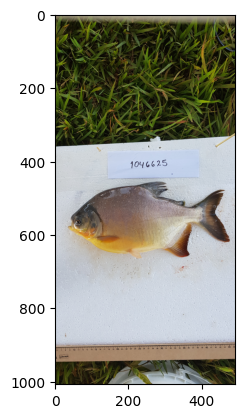

In [ ]:
#pegar nome das imagens sem o \n

import csv
nome = linhas[0][0:25]
print(nome)

image = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/"+nome+".png").convert("RGB")
# image = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/peixe91_gradcam_preto3.png').convert("RGB")

cont=1
i=2
teste = 0.656565
print("peixe"+str(cont)+"_gradcam_preto"+str(i)+".png")

output2 = model([F.to_tensor(image)])[0]
print(type(output2), output2.keys())

plt.imshow(image)

with open("/content/drive/MyDrive/Colab Notebooks/XAI/GradCam_Preto/indices_gradcam_preto.csv", "w", newline="") as csvfile:
        spamwriter = csv.writer(csvfile, delimiter=";",
                                quotechar="|", quoting=csv.QUOTE_MINIMAL)
        spamwriter.writerow([nome, teste, cont, i])



In [ ]:
class SegmentationModelOutputWrapper(torch.nn.Module):
    def __init__(self, model):
        super(SegmentationModelOutputWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model([F.to_tensor(x)])[0]["masks"]

In [ ]:
from pytorch_grad_cam import GradCAM
import random

class SemanticSegmentationTarget:
    def __init__(self, category, mask):
        self.category = category
        self.mask = torch.from_numpy(mask)

    def __call__(self, model_output):
        return (model_output['masks'][self.category, :, : ] * self.mask).sum()

In [ ]:
import csv


def CalcularIndices(copia_img, mask_cam, nome, cont, i):

      # print("entrou")

      Image.fromarray(np.uint8(copia_img)).save("/content/drive/MyDrive/Colab Notebooks/XAI/GradCam_Aleatorio/peixe"+str(cont)+"_gradcam_aleatorio"+str(i)+".png")

      # print("peixe"+str(cont)+"_gradcam_preto"+str(i)+".png")

      img_mask = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Máscaras peixes/"+nome+".png")
      mascara_original = np.asarray(img_mask)

      #intersecção sobre a união
      a = np.uint8(mask_cam)
      b = np.uint8(mascara_original)


      mask1_area = np.count_nonzero(a == 1)
      mask2_area = np.count_nonzero(b == 1)
      intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
      iou = intersection/(mask1_area+mask2_area-intersection)

      # print(iou)


      #sorense dice
      dice = np.sum(mask_cam[mascara_original==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_original))

      # print(dice)


      with open("/content/drive/MyDrive/Colab Notebooks/XAI/GradCam_Aleatorio/indices_gradcam_aleatorio.csv", "a", newline="") as csvfile:
        spamwriter = csv.writer(csvfile, delimiter=";", quotechar="|", quoting=csv.QUOTE_MINIMAL, lineterminator='\n')
        spamwriter.writerow([cont, nome, str(iou), str(dice), i])





In [ ]:
cont = 0

for imagens in linhas:
  cont += 1
  nome = imagens[0:25]
  print(nome)
  image = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/"+nome+".png").convert("RGB")
  for a in [1,2,3,4,5]:
    try:
      print(a)
      if a>1:
        num = a-1
        image = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/GradCam_Aleatorio/peixe"+str(cont)+"_gradcam_aleatorio"+str(num)+".png").convert("RGB")

      output2 = model([F.to_tensor(image)])[0]

      #parte que dá erro

      segmodel = SegmentationModelOutputWrapper(model)
      output = segmodel(image)
      output[0].shape


      #máscaras da predição

      output = segmodel(image)
      normalized_masks = torch.nn.functional.softmax(output, dim=1).cpu()

      sem_classes = [
          'nadadeiras','corpo', 'cabeca'
      ]
      sem_class_to_idx = {cls: idx for (idx, cls) in enumerate(sem_classes)}

      copia_img =  np.float32(image.convert("RGB"))

      mascaras_todas = np.zeros((copia_img.shape[0], copia_img.shape[1]))

      for p in output2['masks']:
        t = p.squeeze().detach().cpu().numpy()
        for i in range(len(t)):
          for j in range(len(t[i])):
              if t[i][j]>0.5:
                mascaras_todas[i][j] = 1

      car_mask = torch.from_numpy(mascaras_todas)
      mask = car_mask.clone().detach().numpy()

      #aplicacao grad-cam

      target_layers = [model.backbone[7]]

      targets = [SemanticSegmentationTarget(None, mascaras_todas)]



      with GradCAM(model=model, target_layers=target_layers) as cam:
          grayscale_cam = cam(input_tensor=F.to_tensor(image).unsqueeze(dim=0),targets=targets)[0, :]
          rgb_img = np.float32(image.convert("RGB")) / 255

          grayscale_cam = np.moveaxis(grayscale_cam, 0, 0)
          # print(rgb_img.shape)
          # print(grayscale_cam.shape)
          cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)


          #Pertubação de pixels
          copia_img =  np.float32(image.convert("RGB"))

          #Matriz zerada da imagem
          mask_cam = np.zeros((copia_img.shape[0], copia_img.shape[1]))

          #RGB - preto
          # for i in range(len(grayscale_cam)):
          #   # print("for 1")
          #   for j in range(len(grayscale_cam[i])):
          #     # print("for 2")
          #     if grayscale_cam[i][j]>0.01:
          #       copia_img [i][j][0] = 0
          #       copia_img [i][j][1] = 0
          #       copia_img [i][j][2] = 0
          #       mask_cam [i][j] = 1
          #     # print(grayscale_cam[i][j])

          #Pixels Aleatórios

          for i in range(len(grayscale_cam)):
            for j in range(len(grayscale_cam[i])):
              if grayscale_cam[i][j]>0.01:
                copia_img [i][j][0] = random.randint(0, 255)
                copia_img [i][j][1] = random.randint(0, 255)
                copia_img [i][j][2] = random.randint(0, 255)
                mask_cam [i][j] = 1

      CalcularIndices(copia_img, mask_cam, nome, cont, a)

    except:
        break



ckz4dow5r8eay0z9i9oef91zg
1
2
3
ckz4e0jvq8h73109bbpqs0fps
1
2
ckz4e2n4q8f530z8n9s3ubp7y
1
2
3
ckz4e3onq8gmi0z9i5c70ay45
1
2
ckz4e4vvo8i6i109bgzla6hms
1
2
ckz4e8ge48hhl0z9ifd9773xk
1
2
3
4
5
ckz4e9ebq8gg20z8ngztba1ez
1
2
ckz4e650k8ig1109b97k528nn
1
2
ckz4e72918ion109b5wbr5raw
1
2
ckz4ea3cz8jbf109bhn9y68q1
1
2
ckz4ebk6g8i8u0z9i60n60f6l
1
2
ckz4edumg8ing0z9ifni9g5t8
1
2
ckz4efrf38kem109b2057fb9a
1
2
3
4
5
ckz4egfr48kh7109bah7xf5az
1
2
ckz4fduq78ntw0z8n630rag87
1
2
3
ckz4ff6t28o3e0z8neshr668d
1
2
3
4
ckz4ffyse8o9s0z8n3zgmd73e
1
2
3
ckz4fhxu88ool0z8n6rwr1cpm
1
2
ckz4fiupe8rhx109bh3peeyhc
1
2
3
ckz4fzcn28sui0z8nakiacny4
1
2
ckz4g2msm8tqx0z8n6d9pb3iv
1
2
3
ckz4g4h098uag0z8nht9q26i8
1
2
ckz4g5tsc8um20z8n9i7a5xw6
1
2
3
ckz4g6h9v8x8e109b16pefhfo
1
2
3
4
5
ckz4g7nl08v2x0z8nbuek2vjk
1
2
3
4
5
ckz4g09s18vbm109bhm9pcd53
1
2
3
4
5
ckz4g9uib8x7y0z9i2x6dgzf8
1
2
ckz4g17ra8upt0z9ibj0bbdno
1
2
ckz4g51wk8wtj109bhzrydupk
1
2
3
4
ckz4g70yq8we70z9idki606ak
1
2
ckz4g39038vcp0z9i67o96efj
1
2
3
ckz4g88978v9h0z8

Now, lets run the model on the image, and show which pixels are predicted as belonging to the car mask.

In [ ]:
output = segmodel(image)
normalized_masks = torch.nn.functional.softmax(output, dim=1).cpu()

sem_classes = [
    'nadadeiras','corpo', 'cabeca'
]
sem_class_to_idx = {cls: idx for (idx, cls) in enumerate(sem_classes)}

# minha_categoria = sem_class_to_idx["corpo"]
# minha_categoria_nada = sem_class_to_idx["nadadeiras"]
# minha_categoria_cabeca = sem_class_to_idx["cabeca"]

# # corpo
# car_mask = output[minha_categoria]
# car_mask = car_mask[0,:,:].detach().cpu().numpy()
# car_mask_uint8 = 255 * np.uint8(car_mask > 0.5)
# car_mask_float = np.float32(car_mask > 0.5)

# # nadadeiras
# car_mask_nada = output[minha_categoria_nada]
# car_mask_nada = car_mask_nada[0,:,:].detach().cpu().numpy()
# car_mask_nada_uint8 = 255 * np.uint8(car_mask_nada > 0.5)
# car_mask_nada_float = np.float32(car_mask_nada > 0.5)

# #cabeça
# car_mask_cabeca = output[minha_categoria_cabeca]
# car_mask_cabeca = car_mask_cabeca[0,:,:].detach().cpu().numpy()
# car_mask_cabeca_uint8 = 255 * np.uint8(car_mask_cabeca > 0.5)
# car_mask_cabeca_float = np.float32(car_mask_cabeca > 0.5)

copia_img =  np.float32(image.convert("RGB"))

mascaras_todas = np.zeros((copia_img.shape[0], copia_img.shape[1]))

for p in output2['masks']:
  t = p.squeeze().detach().cpu().numpy()
  for i in range(len(t)):
    for j in range(len(t[i])):
        if t[i][j]>0.5:
          mascaras_todas[i][j] = 1


# Image.fromarray(np.uint8(mascaras_todas))

# both_images = np.hstack((image, np.repeat(car_mask_nada_uint8[:, :, None], 3, axis=-1)))
# Image.fromarray(both_images)

In [ ]:
car_mask = torch.from_numpy(mascaras_todas)
mask = car_mask.clone().detach().numpy()
# car_mask_cabeca_uint8 = 255 * np.uint8(car_mask_cabeca > 0.5)
# car_mask_cabeca_float = np.float32(car_mask_cabeca > 0.5)

In [ ]:
model.backbone[5]

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-

(1032, 774, 3)
(1032, 774)


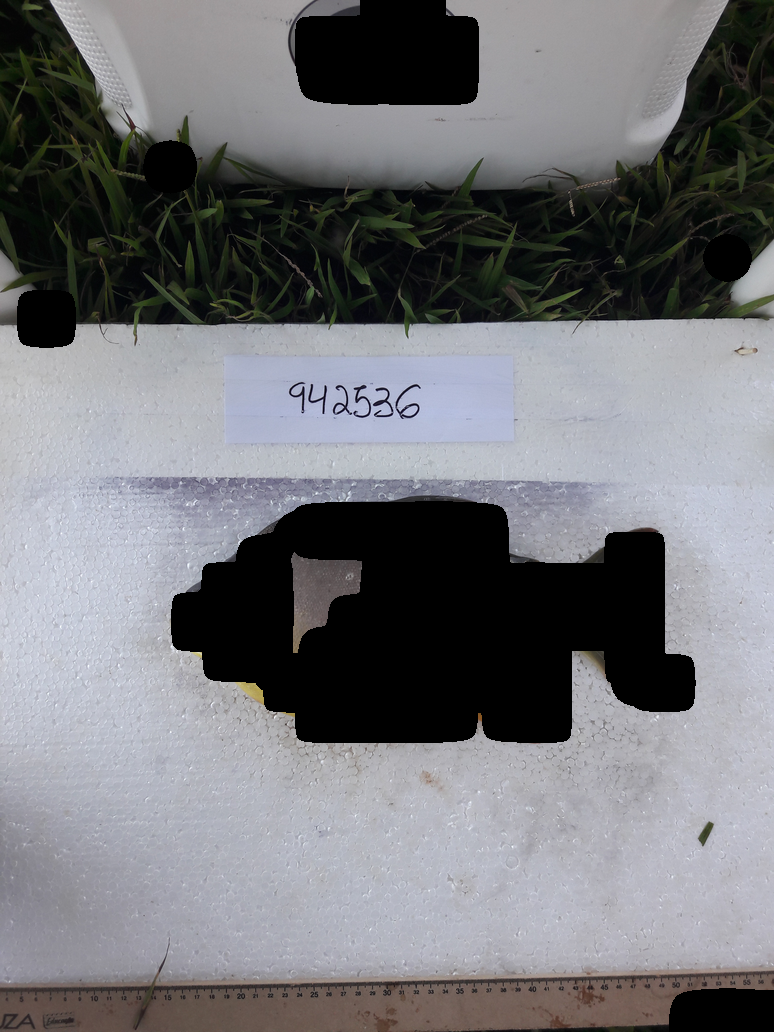

In [ ]:
from pytorch_grad_cam import GradCAM
import random

class SemanticSegmentationTarget:
    def __init__(self, category, mask):
        self.category = category
        self.mask = torch.from_numpy(mask)

    def __call__(self, model_output):
        return (model_output['masks'][self.category, :, : ] * self.mask).sum()


target_layers = [model.backbone[7]]

# targets = [SemanticSegmentationTarget(minha_categoria, car_mask_float)]
# targets_nada = [SemanticSegmentationTarget(minha_categoria_nada, car_mask_nada_float)]
# targets_cabeca = [SemanticSegmentationTarget(minha_categoria_cabeca, car_mask_cabeca_float)]

targets = [SemanticSegmentationTarget(None, mascaras_todas)]



with GradCAM(model=model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=F.to_tensor(image).unsqueeze(dim=0),targets=targets)[0, :]
    rgb_img = np.float32(image.convert("RGB")) / 255





    grayscale_cam = np.moveaxis(grayscale_cam, 0, 0)
    print(rgb_img.shape)
    print(grayscale_cam.shape)
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)


#Código implementado pela Ju - Pertubação de pixels
    copia_img =  np.float32(image.convert("RGB"))

    #Matriz zerada da imagem
    mask_cam = np.zeros((copia_img.shape[0], copia_img.shape[1]))

    #RGB - preto
    for i in range(len(grayscale_cam)):
      for j in range(len(grayscale_cam[i])):
        if grayscale_cam[i][j]>0.01:
          copia_img [i][j][0] = 0
          copia_img [i][j][1] = 0
          copia_img [i][j][2] = 0
          mask_cam [i][j] = 1
         # print(grayscale_cam[i][j])



    #White Noise

    # for i in range(len(grayscale_cam)):
    #   for j in range(len(grayscale_cam[i])):
    #     if grayscale_cam[i][j]>0.01:
    #       rdn = random.random()
    #       if rdn < 0.5:
    #         copia_img [i][j][0] = 0
    #         copia_img [i][j][1] = 0
    #         copia_img [i][j][2] = 0
    #       elif rdn > 0.5:
    #         copia_img [i][j][0] = 255
    #         copia_img [i][j][1] = 255
    #         copia_img [i][j][2] = 255
    #       mask_cam [i][j] = 1



    #Pixels Aleatórios

    # for i in range(len(grayscale_cam)):
    #   for j in range(len(grayscale_cam[i])):
    #     if grayscale_cam[i][j]>0.01:
    #       copia_img [i][j][0] = random.randint(0, 255)
    #       copia_img [i][j][1] = random.randint(0, 255)
    #       copia_img [i][j][2] = random.randint(0, 255)
    #       mask_cam [i][j] = 1


Image.fromarray(np.uint8(copia_img)).save('/content/drive/MyDrive/Colab Notebooks/XAI/peixe92_gradcam_preto1.png')

# print(car_mask_nada_float.shape)

Image.fromarray(np.uint8(copia_img))

In [ ]:
#Ler mascara dos 100 peixes
#92
img_mask = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/Máscaras peixes/ckz4hgbuc95io0z8n6fp75rkj.png')
mascara_original = np.asarray(img_mask)

print(mascara_original.shape)

(1032, 774)


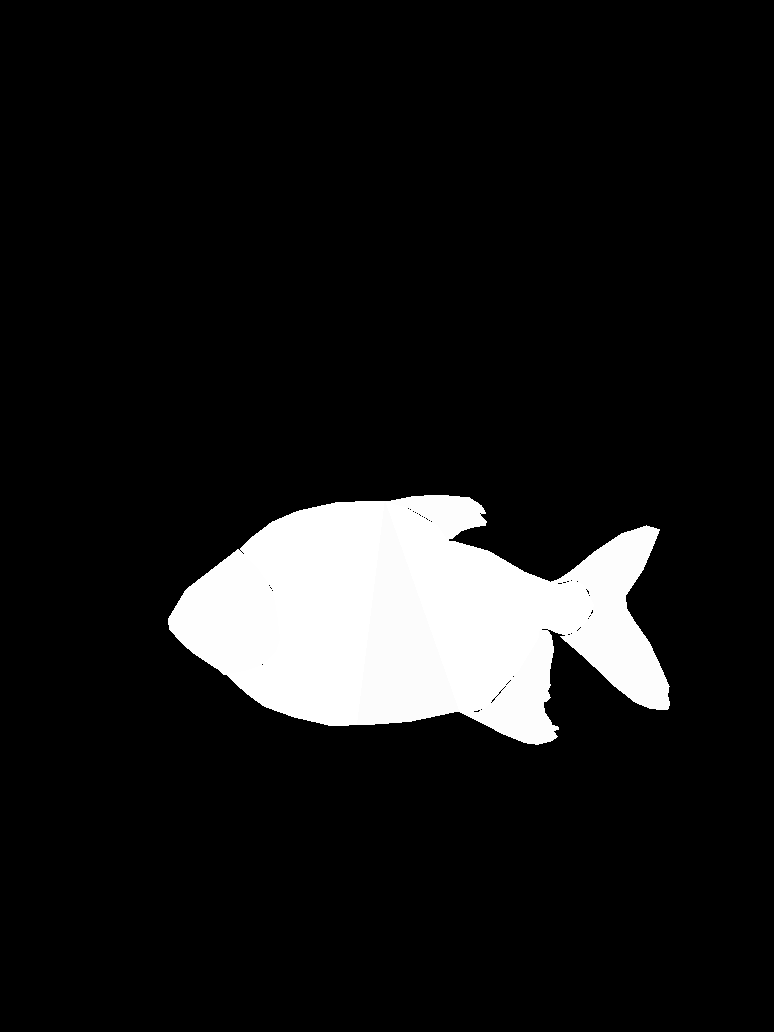

In [ ]:

Image.fromarray(np.uint8(mascara_original)*255).convert('RGB')

In [ ]:
#intersecção sobre a união
a = np.uint8(mask_cam)
b = np.uint8(mascara_original)
# b = np.uint8(mascaras_todas)
# b = np.uint8(car_mask_nada_float)
# b = np.uint8(car_mask_cabeca_float)
# b = np.uint8(car_mask_float)

mask1_area = np.count_nonzero(a == 1)
mask2_area = np.count_nonzero(b == 1)
intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
iou = intersection/(mask1_area+mask2_area-intersection)

print(iou)

0.31044546725419186


In [ ]:
#indice sorensen_dice
dice = np.sum(mask_cam[mascara_original==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_original))
# dice = np.sum(mask_cam[mascaras_todas==1])*2.0 / (np.sum(mask_cam) + np.sum(mascaras_todas))
# dice = np.sum(mask_cam[car_mask_nada_float==1])*2.0 / (np.sum(mask_cam) + np.sum(car_mask_nada_float))
# dice = np.sum(mask_cam[car_mask_cabeca_float==1])*2.0 / (np.sum(mask_cam) + np.sum(car_mask_cabeca_float))
# dice = np.sum(mask_cam[car_mask_float==1])*2.0 / (np.sum(mask_cam) + np.sum(car_mask_float))
print(dice)

0.2745611244468867


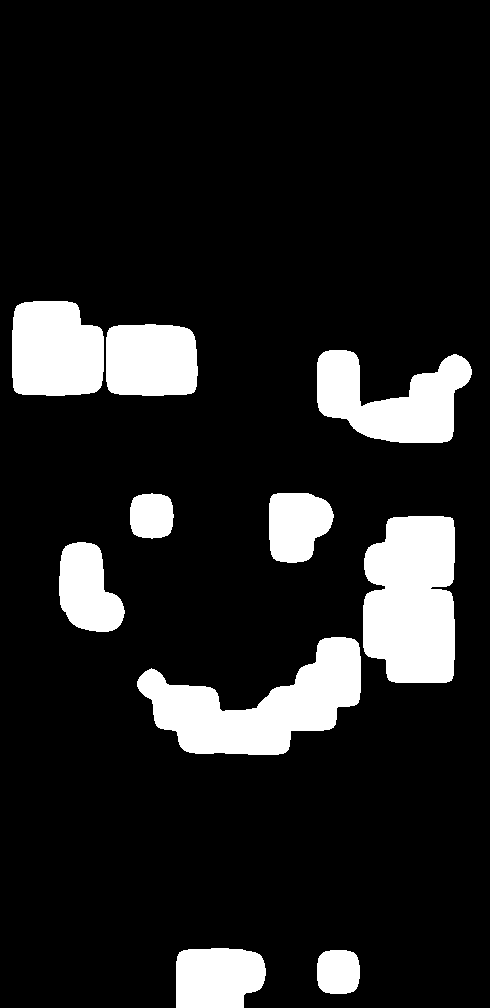

In [ ]:
Image.fromarray(np.uint8(mask_cam)*255).convert('RGB')
#print(mask_cam[mask_cam>0])



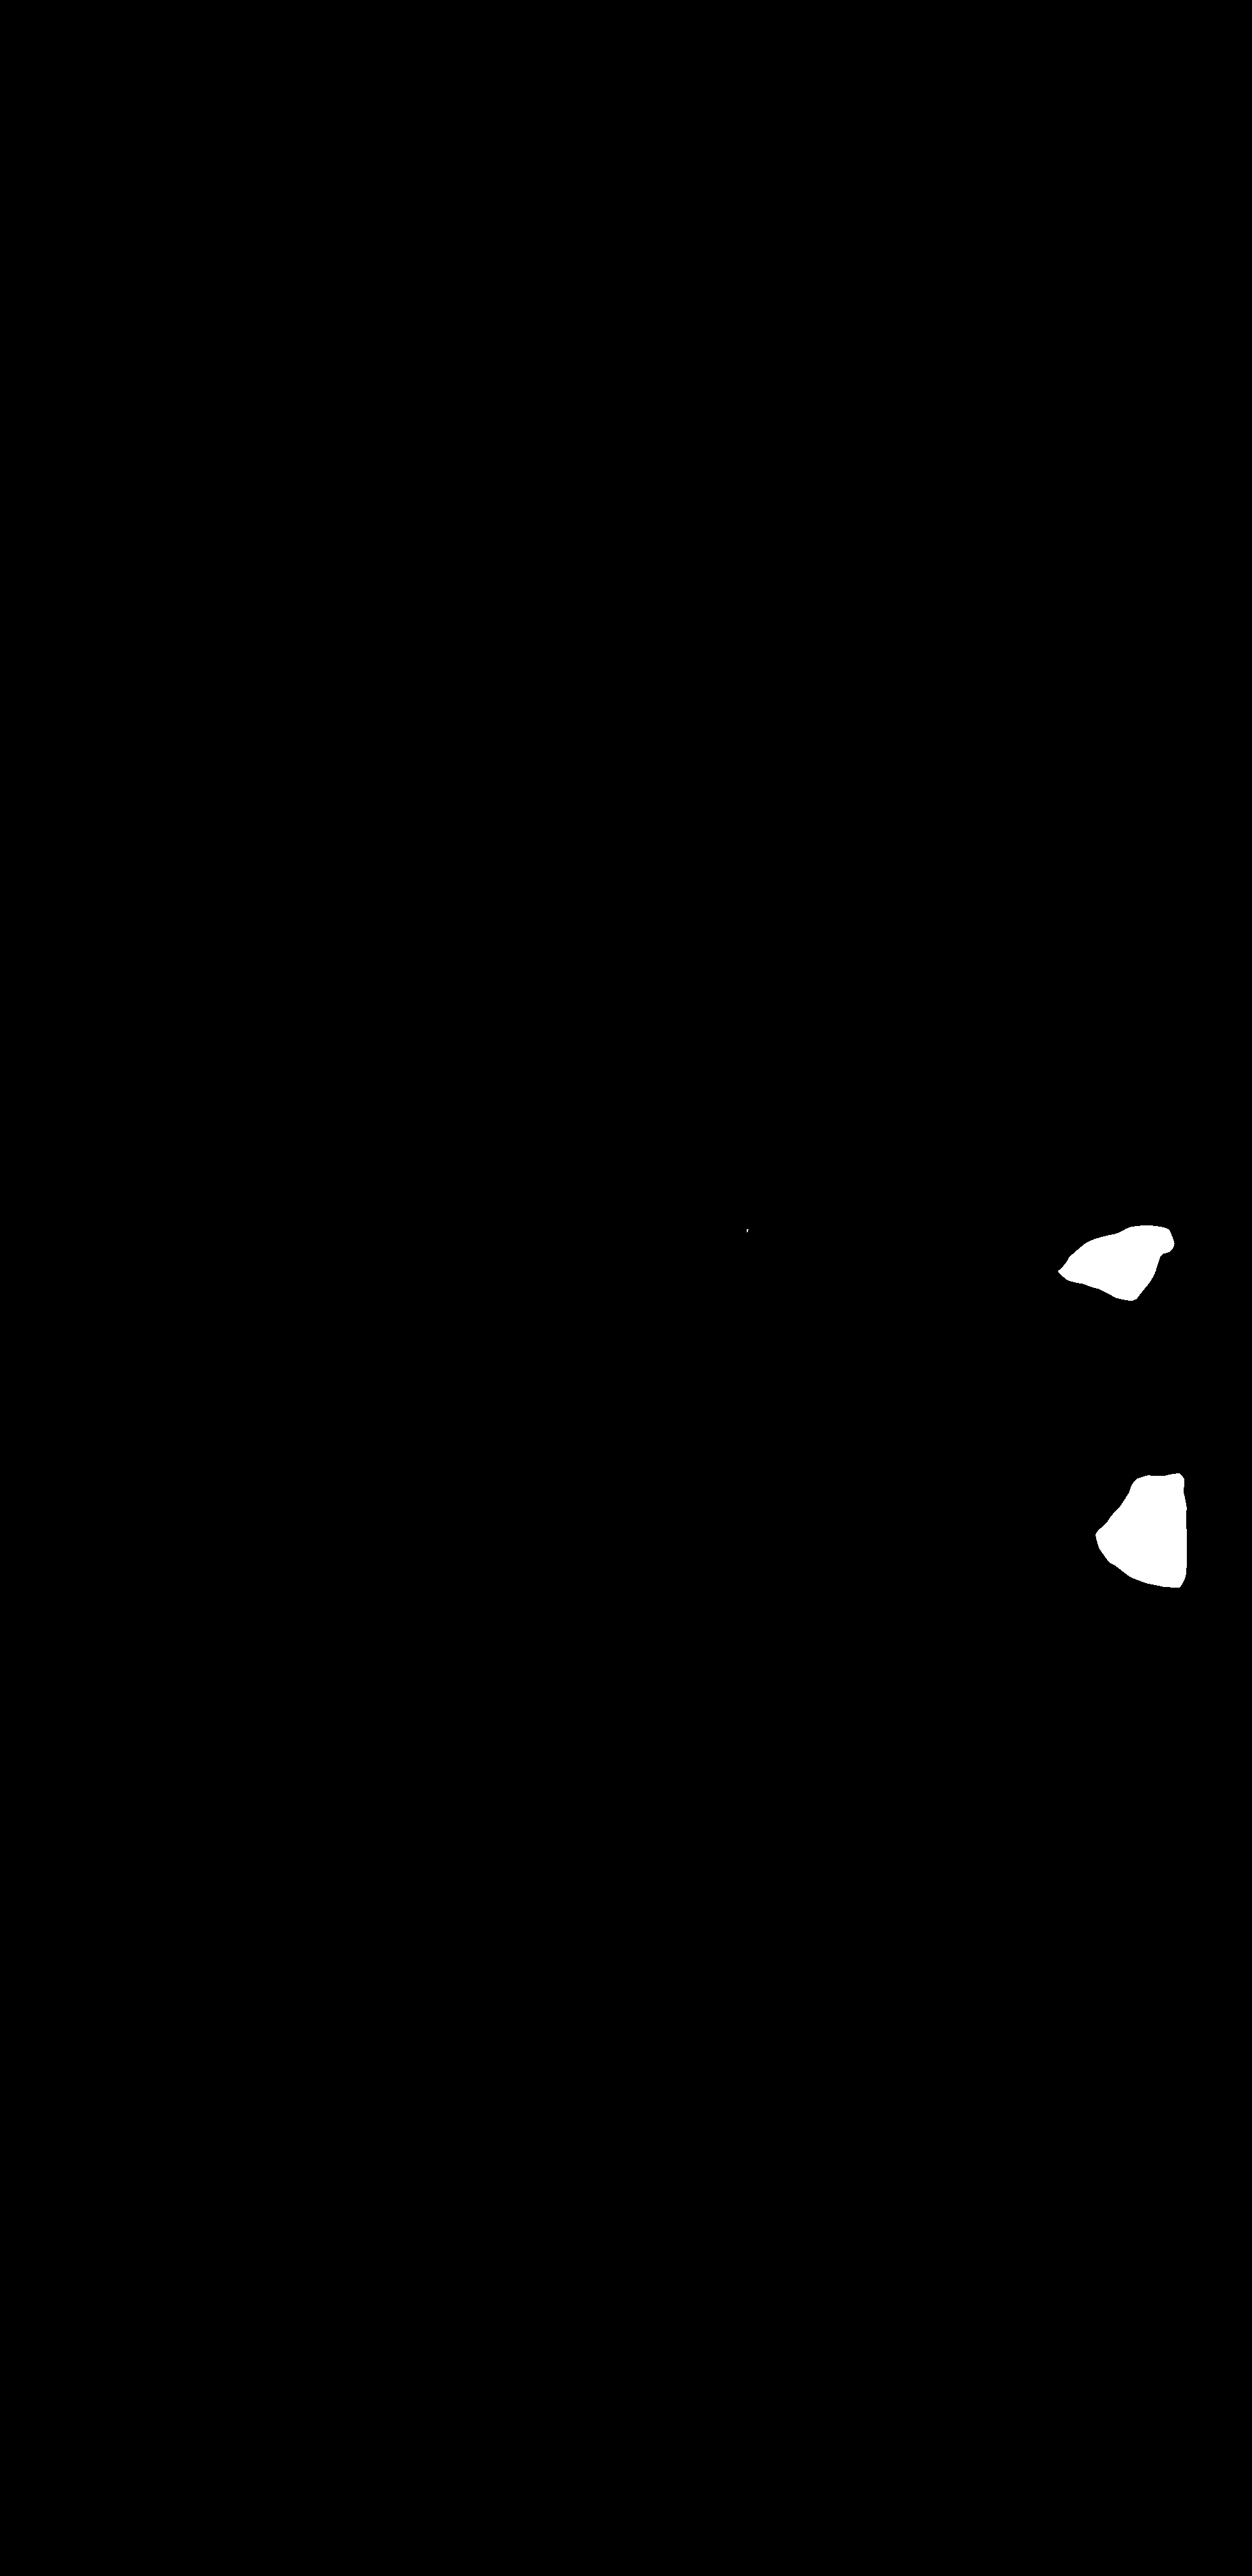

In [ ]:
# Image.fromarray(np.uint8(car_mask_nada_float)*255).convert('RGB')
# Image.fromarray(np.uint8(car_mask_cabeca_float)*255).convert('RGB')
# Image.fromarray(np.uint8(car_mask_float)*255).convert('RGB')
Image.fromarray(np.uint8(mascaras_todas)*255).convert('RGB')
#print(car_mask_nada_float[car_mask_nada_float>0])

Notice how we're getting pixels outside the otirinal masks as well. This is because every pixel is affected by it's sourrounding pixels as well.

# Mapa de Saliência


In [ ]:
import torch
import torchvision
import  torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
from matplotlib import pyplot as plt
from time import time
import numpy as np
import cv2
import torch

#-----model of the fishes (Fabrício)
model = get_maskrcnn_model(num_classes=4, FROZEN_BLOCKS=1)

#original do Fabrício
#model.load_state_dict(torch.load('./resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))

#feito pela Ju
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/XAI/resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))


#-----original model of the saliency map
#model = torchvision.models.resnet50(pretrained=True)

#-----original model of the grad cam
#model = resnet50(pretrained=True)




#vale para o modelo do Fabrício?

#define transforms to preprocess input image into format expected by model
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
#inverse transform to get normalize image back to original form for visualization
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.255],
    std=[1/0.229, 1/0.224, 1/0.255]
)

#transforms to resize image to the size expected by pretrained model,
#convert PIL image to tensor, and
#normalize the image
transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.ToTensor(),
    #normalize,
])





In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
from torchvision.models.segmentation import deeplabv3_resnet50
import torch
import torch.functional as F
import numpy as np
import requests
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import requests
from io import BytesIO
from PIL import Image, ExifTags, ImageFile
from torchvision.transforms import functional as F

arq = open("/content/drive/MyDrive/Colab Notebooks/XAI/nomes_imagens_peixes2.txt")
linhas = arq.readlines()

for linha in linhas:
    print(linha)

ckz4dow5r8eay0z9i9oef91zg

ckz4e0jvq8h73109bbpqs0fps

ckz4e2n4q8f530z8n9s3ubp7y

ckz4e3onq8gmi0z9i5c70ay45

ckz4e4vvo8i6i109bgzla6hms

ckz4e8ge48hhl0z9ifd9773xk

ckz4e9ebq8gg20z8ngztba1ez

ckz4e650k8ig1109b97k528nn

ckz4e72918ion109b5wbr5raw

ckz4ea3cz8jbf109bhn9y68q1

ckz4ebk6g8i8u0z9i60n60f6l

ckz4edumg8ing0z9ifni9g5t8

ckz4efrf38kem109b2057fb9a

ckz4egfr48kh7109bah7xf5az

ckz4fduq78ntw0z8n630rag87

ckz4ff6t28o3e0z8neshr668d

ckz4ffyse8o9s0z8n3zgmd73e

ckz4fhxu88ool0z8n6rwr1cpm

ckz4fiupe8rhx109bh3peeyhc

ckz4fzcn28sui0z8nakiacny4

ckz4g2msm8tqx0z8n6d9pb3iv

ckz4g4h098uag0z8nht9q26i8

ckz4g5tsc8um20z8n9i7a5xw6

ckz4g6h9v8x8e109b16pefhfo

ckz4g7nl08v2x0z8nbuek2vjk

ckz4g09s18vbm109bhm9pcd53

ckz4g9uib8x7y0z9i2x6dgzf8

ckz4g17ra8upt0z9ibj0bbdno

ckz4g51wk8wtj109bhzrydupk

ckz4g70yq8we70z9idki606ak

ckz4g39038vcp0z9i67o96efj

ckz4g88978v9h0z8n0bmhf6m2

ckz4gb3qw8yne109bd7k39lcl

ckz4gbrb08xqo0z9i6tencxws

ckz4gceez8xwm0z9ihjmr0f68

ckz4gd9eh8y3f0z9i649mbt2l

ckz4gds8l8zdg109b2j93eman

c

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def saliency(img, model):
    #we don't need gradients w.r.t. weights for a trained model
    for param in model.parameters():
        param.requires_grad = False

    #set model in eval model
    model.eval()

    #transoform input PIL image to torch.Tensor and normalize
    input = transform(img)
    input.unsqueeze_(0)

    #we want to calculate gradient of higest score w.r.t. input
    #so set requires_grad to True for input
    input.requires_grad = True


    #forward pass to calculate predictions
    preds = model(input)

    score, indices = torch.max((preds[0]['masks']), 1)



    #-------colocado pela Ju
    score.mean().backward()
    #print(score.sum())


    #get max along channel axis
    slc, _ = torch.max(torch.abs(input.grad[0]), dim=0)

    slc = (slc - slc.min())/(slc.max()-slc.min())
    #apply inverse transform on image

    #usa a normalização - tirei porque talvez estivesse atrapalhando o modelo do Fabrício
    '''with torch.no_grad():
        input_img = inv_normalize(input[0])'''


    return slc, preds

In [ ]:
import csv


def CalcularIndices2(copia_img, mask_cam, nome, cont, i):



      Image.fromarray(np.uint8(copia_img)).save("/content/drive/MyDrive/Colab Notebooks/XAI/MapaSaliencia_Aleatorio/peixe"+str(cont)+"_mapa_aleatorio"+str(i)+".png")

      # print("peixe"+str(cont)+"_gradcam_preto"+str(i)+".png")

      img_mask = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Máscaras peixes/"+nome+".png")
      mascara_original = np.asarray(img_mask)

      #intersecção sobre a união
      a = np.uint8(mask_cam)
      b = np.uint8(mascara_original)


      mask1_area = np.count_nonzero(a == 1)
      mask2_area = np.count_nonzero(b == 1)
      intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
      iou = intersection/(mask1_area+mask2_area-intersection)

      # print(iou)


      #sorense dice
      dice = np.sum(mask_cam[mascara_original==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_original))

      # print(dice)


      with open("/content/drive/MyDrive/Colab Notebooks/XAI/MapaSaliencia_Aleatorio/indices_mapasaliencia_aleatorio.csv", "a", newline="") as csvfile:
        spamwriter = csv.writer(csvfile, delimiter=";", quotechar="|", quoting=csv.QUOTE_MINIMAL, lineterminator='\n')
        spamwriter.writerow([cont, nome, str(iou), str(dice), i])






In [ ]:
import random

contador = 0

for imagens in linhas:
  contador += 1
  nome = imagens[0:25]
  print(nome)
  imagem = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/"+nome+".png").convert("RGB")
  for c in [1,2,3,4,5]:
    try:
      print(c)
      if c>1:
        num2 = c-1
        imagem = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/MapaSaliencia_Aleatorio/peixe"+str(contador)+"_mapa_aleatorio"+str(num2)+".png").convert("RGB")

      model.eval()
      output = model([F.to_tensor(imagem)])[0]

      slc, preds = saliency(imagem, model)


      #Pertubação de pixels

      copia_img =  np.float32(imagem.convert("RGB"))

      #Matriz zerada da imagem
      mask_cam = np.zeros((copia_img.shape[0], copia_img.shape[1]))


      # #RGB - Preto
      # for i in range(len(slc)):
      #  for j in range(len(slc[i])):
      #     if slc[i][j]>0.045:
      #        copia_img [i][j][0] = 0
      #        copia_img [i][j][1] = 0
      #        copia_img [i][j][2] = 0
      #        mask_cam [i][j] = 1
      #       # print(grayscale_cam[i][j])


      # #White Noise

      # for i in range(len(slc)):
      #   for j in range(len(slc[i])):
      #     if slc[i][j]>0.045:
      #       rdn = random.random()
      #       if rdn < 0.5:
      #         copia_img [i][j][0] = 0
      #         copia_img [i][j][1] = 0
      #         copia_img [i][j][2] = 0
      #       elif rdn > 0.5:
      #         copia_img [i][j][0] = 255
      #         copia_img [i][j][1] = 255
      #         copia_img [i][j][2] = 255
      #       mask_cam [i][j] = 1
      #         # print(grayscale_cam[i][j])

      #Pixels Aleatórios


      for i in range(len(slc)):
        for j in range(len(slc[i])):
          if slc[i][j]>0.045:
            copia_img [i][j][0] = random.randint(0, 255)
            copia_img [i][j][1] = random.randint(0, 255)
            copia_img [i][j][2] = random.randint(0, 255)
            mask_cam [i][j] = 1


      CalcularIndices2(copia_img, mask_cam, nome, contador, c)

    except:
        break



ckz4dow5r8eay0z9i9oef91zg
1
2
ckz4e0jvq8h73109bbpqs0fps
1
2
ckz4e2n4q8f530z8n9s3ubp7y
1
2
ckz4e3onq8gmi0z9i5c70ay45
1
2
ckz4e4vvo8i6i109bgzla6hms
1
2
ckz4e8ge48hhl0z9ifd9773xk
1
2
ckz4e9ebq8gg20z8ngztba1ez
1
2
ckz4e650k8ig1109b97k528nn
1
2
ckz4e72918ion109b5wbr5raw
1
2
ckz4ea3cz8jbf109bhn9y68q1
1
2
3
ckz4ebk6g8i8u0z9i60n60f6l
1
2
3
4
5
ckz4edumg8ing0z9ifni9g5t8
1
2
ckz4efrf38kem109b2057fb9a
1
2
ckz4egfr48kh7109bah7xf5az
1
2
ckz4fduq78ntw0z8n630rag87
1
2
ckz4ff6t28o3e0z8neshr668d
1
2
ckz4ffyse8o9s0z8n3zgmd73e
1
2
ckz4fhxu88ool0z8n6rwr1cpm
1
2
ckz4fiupe8rhx109bh3peeyhc
1
2
ckz4fzcn28sui0z8nakiacny4
1
2
3
4
ckz4g2msm8tqx0z8n6d9pb3iv
1
2
3
ckz4g4h098uag0z8nht9q26i8
1
2
ckz4g5tsc8um20z8n9i7a5xw6
1
2
ckz4g6h9v8x8e109b16pefhfo
1
2
ckz4g7nl08v2x0z8nbuek2vjk
1
2
ckz4g09s18vbm109bhm9pcd53
1
2
ckz4g9uib8x7y0z9i2x6dgzf8
1
2
ckz4g17ra8upt0z9ibj0bbdno
1
2
3
ckz4g51wk8wtj109bhzrydupk
1
2
ckz4g70yq8we70z9idki606ak
1
2
ckz4g39038vcp0z9i67o96efj
1
2
ckz4g88978v9h0z8n0bmhf6m2
1
2
3
ckz4gb3qw8yne109bd7k39

<class 'dict'> dict_keys(['boxes', 'labels', 'scores', 'masks'])
{'boxes': tensor([[217.2218, 455.6471, 478.5383, 662.7647],
        [ 84.9249, 467.1131, 403.1178, 651.0221],
        [ 33.6221, 509.6259, 130.3827, 613.3697]], grad_fn=<StackBackward0>), 'labels': tensor([3, 1, 2]), 'scores': tensor([1.0000, 0.9999, 0.9992], grad_fn=<IndexBackward0>), 'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0.

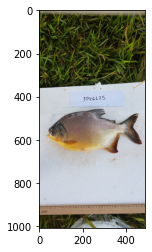

In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
from torchvision.models.segmentation import deeplabv3_resnet50
import torch
import torch.functional as F
import numpy as np
import requests
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import requests
from io import BytesIO
from PIL import Image, ExifTags, ImageFile
from torchvision.transforms import functional as F

# image_url = "https://storage.labelbox.com/ckmcqrqarbc4b0772go0ytxbv%2Fbbc080c6-b553-a2bf-a93c-1891d0ec5a73-1046625.jpg?Expires=1646779590485&KeyName=labelbox-assets-key-3&Signature=2RrFjc6Ic6x0AxXe7lX2ukECskE"
# img = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

#Pertubação de pixels
# img = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/peixe1_mapasaliencia_rgb1.png').convert("RGB")

#100 peixes
img = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/ckz4dow5r8eay0z9i9oef91zg.png').convert("RGB")

model.eval()
output = model([F.to_tensor(img)])[0]
print(type(output), output.keys())
print(output)

plt.imshow(img)

[{'boxes': tensor([[217.2218, 455.6471, 478.5383, 662.7647],
        [ 84.9249, 467.1131, 403.1178, 651.0221],
        [ 33.6221, 509.6259, 130.3827, 613.3697]], grad_fn=<StackBackward0>), 'labels': tensor([3, 1, 2]), 'scores': tensor([1.0000, 0.9999, 0.9992], grad_fn=<IndexBackward0>), 'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0

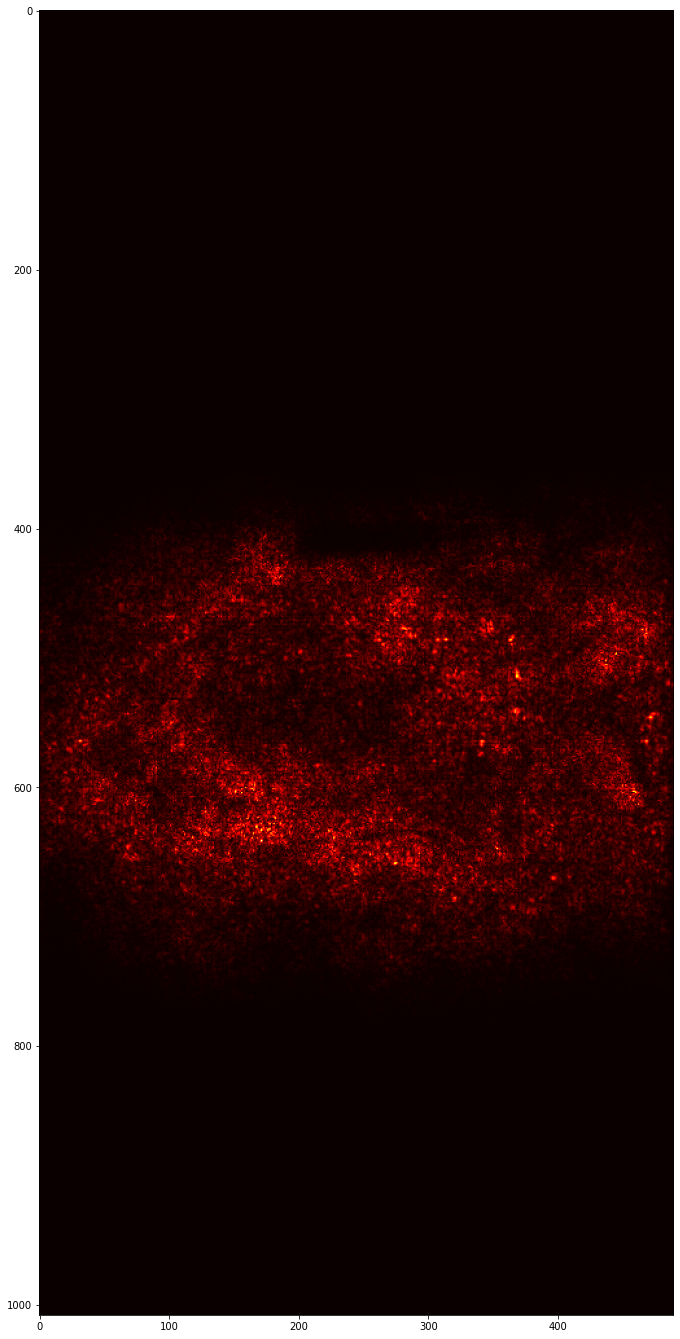

In [ ]:
slc, preds = saliency(img, model)


In [ ]:
slc[slc[:,:] > 0.5]

tensor([0.5240, 0.5360, 0.6090, 0.5154, 0.5297, 0.6091, 0.5245, 0.5151, 0.5946,
        0.6302, 0.6092, 0.5648, 0.5522, 0.5690, 0.7302, 0.6406, 0.5251, 0.5058,
        0.6630, 0.5067, 0.5637, 0.5561, 0.5432, 0.5498, 0.5812, 0.5615, 0.5664,
        0.6334, 0.7161, 0.7078, 0.6906, 0.5033, 0.5105, 0.5261, 0.5182, 0.6007,
        0.5123, 0.8175, 0.5006, 0.5704, 0.7813, 0.7086, 0.5027, 0.5753, 0.5662,
        0.5445, 0.6577, 0.6013, 0.8398, 0.7039, 0.6357, 0.5323, 0.5378, 0.6087,
        0.5753, 0.5030, 0.5548, 0.5360, 0.6466, 0.6194, 0.5076, 0.6779, 0.6129,
        0.5509, 0.5765, 0.6141, 0.5185, 0.5089, 0.5033, 0.5402, 0.5795, 0.5469,
        0.5295, 0.5370, 0.5803, 0.6432, 0.5300, 0.5216, 0.5341, 0.5766, 0.6680,
        0.6230, 0.5371, 0.7375, 0.5934, 0.5032, 0.5122, 0.6684, 0.7925, 0.8099,
        0.7342, 0.5708, 0.5785, 0.6279, 0.9020, 0.5440, 0.5274, 0.7441, 0.5260,
        0.5847, 0.5768, 0.6054, 0.5652, 0.5722, 0.6390, 0.5236, 0.6158, 0.5086,
        0.5195, 0.5213, 0.6188, 0.5865, 

In [ ]:
print(preds[0]['masks'][0].shape)

torch.Size([1, 1008, 490])


In [ ]:
#Pegando uma máscara gerada pela execução do modelo
masks = preds[0]['masks'][0].squeeze().detach().cpu().numpy()
masks_uint8 = 255 * np.uint8(masks > 0.5)
masks_float = np.float32(masks_uint8 > 0.5)
print(masks_float[masks_float[:,:] > 0])
print(masks_float.shape)


[1. 1. 1. ... 1. 1. 1.]
(1008, 490)


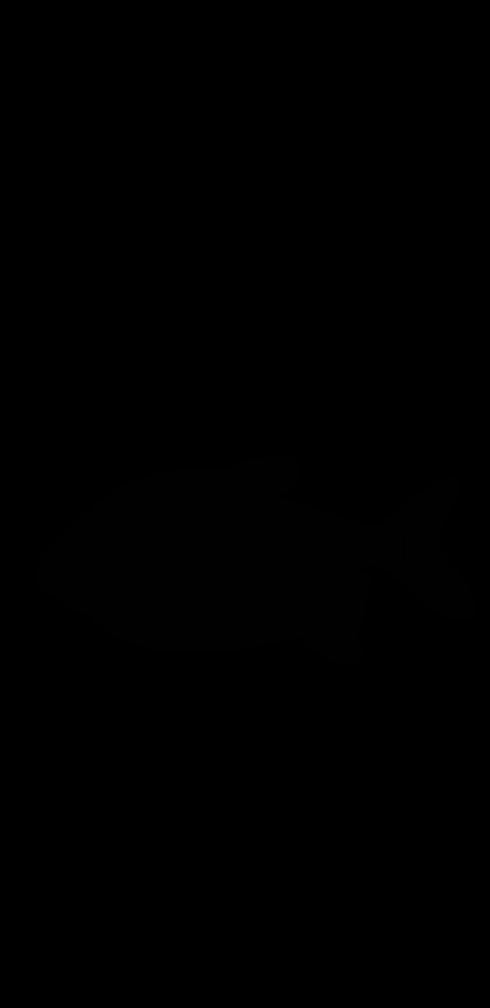

In [ ]:
#Combinação das máscaras
#Imagem ficará preta por conta do valor 1
mascara_merge = np.zeros((copia_img.shape[0], copia_img.shape[1]))

for p in preds[0]['masks']:
  t = p.squeeze().detach().cpu().numpy()
  for i in range(len(t)):
    for j in range(len(t[i])):
        if t[i][j]>0.5:
          mascara_merge[i][j] = 1


Image.fromarray(np.uint8(mascara_merge))

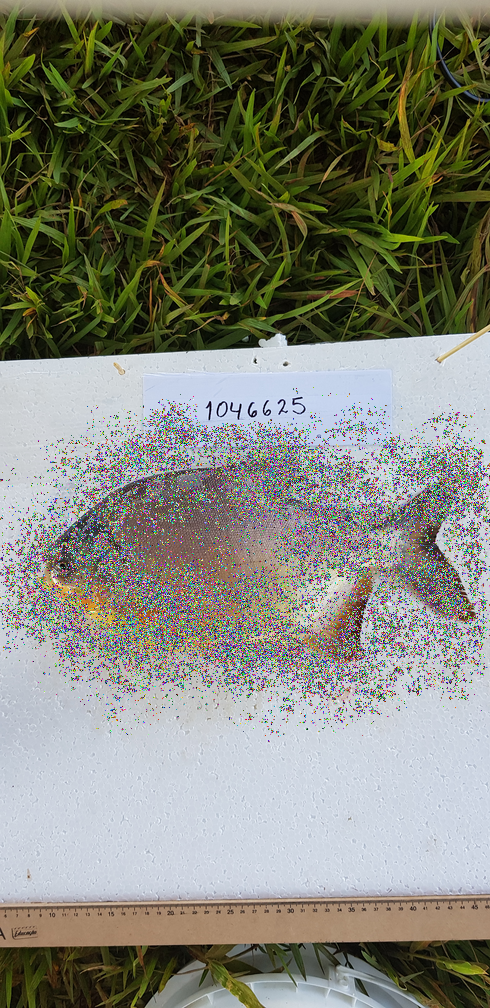

In [ ]:
#Código implementado pela Ju - Pertubação de pixels
# img.show()
copia_img =  np.float32(img.convert("RGB"))

#Matriz zerada da imagem
mask_cam = np.zeros((copia_img.shape[0], copia_img.shape[1]))


# #RGB
# for i in range(len(slc)):
#  for j in range(len(slc[i])):
#     if slc[i][j]>0.045:
#        copia_img [i][j][0] = 255
#        copia_img [i][j][1] = 0
#        copia_img [i][j][2] = 0
#        mask_cam [i][j] = 1
       # print(grayscale_cam[i][j])


#White Noise

# for i in range(len(slc)):
#   for j in range(len(slc[i])):
#     if slc[i][j]>0.045:
#       rdn = random.random()
#       if rdn < 0.5:
#         copia_img [i][j][0] = 0
#         copia_img [i][j][1] = 0
#         copia_img [i][j][2] = 0
#       elif rdn > 0.5:
#         copia_img [i][j][0] = 255
#         copia_img [i][j][1] = 255
#         copia_img [i][j][2] = 255
#       mask_cam [i][j] = 1
#         # print(grayscale_cam[i][j])

#Pixels Aleatórios

#Achei que 0.07 ficou melhor do que 0.045 - testar novamente

for i in range(len(slc)):
  for j in range(len(slc[i])):
    if slc[i][j]>0.07:
      copia_img [i][j][0] = random.randint(0, 255)
      copia_img [i][j][1] = random.randint(0, 255)
      copia_img [i][j][2] = random.randint(0, 255)
      mask_cam [i][j] = 1

#Image.fromarray(cam_image)


Image.fromarray(np.uint8(copia_img)).save('/content/drive/MyDrive/Colab Notebooks/XAI/peixe1_mapasaliencia_rgb1.png')
Image.fromarray(np.uint8(copia_img))

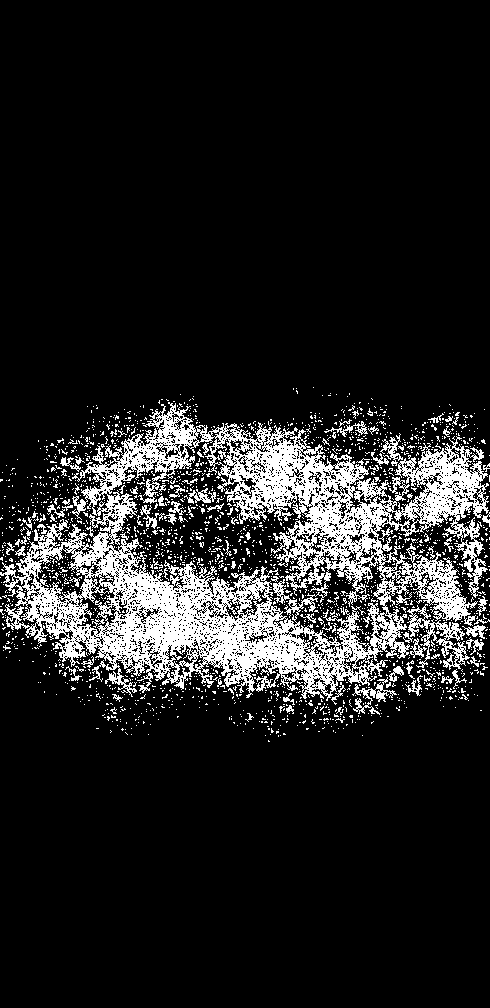

In [ ]:
Image.fromarray(np.uint8(mask_cam)*255).convert('RGB')
# print(masks_float.shape)
# Image.fromarray(np.uint8(masks_float*255), "L")

In [ ]:
#intersecção sobre a união
a = np.uint8(mask_cam)
b = np.uint8(mascara_original)
# b = np.uint8(mascara_merge)

mask1_area = np.count_nonzero(a == 1)
mask2_area = np.count_nonzero(b == 1)
intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
iou = intersection/(mask1_area+mask2_area-intersection)

print(iou)

0.18953338101153058


In [ ]:
#indice sorensen_dice
masks_float = np.uint8(masks_float)
dice = np.sum(mask_cam[mascara_original==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_original))
# dice = np.sum(mask_cam[mascara_merge==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_merge))
print(dice)

0.1681171678500679


#CNN Filters

https://ravivaishnav20.medium.com/visualizing-feature-maps-using-pytorch-12a48cd1e573

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, utils
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import scipy.misc
from PIL import Image
import json
%matplotlib inline

In [ ]:
import numpy as np
import cv2
import torch
from torchvision.models import resnet50


model = get_maskrcnn_model(num_classes=4, FROZEN_BLOCKS=1)
#original
#model.load_state_dict(torch.load('/resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))

#modificado pela Ju - pega arquivo direto do Drive
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/XAI/resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))

model = model.eval()


print(model)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (

In [ ]:
def CnnFilters(imagem, model):


  model_weights =[]

  conv_layers = []

  model_children = list(model.backbone)

  counter = 0
  #append all the conv layers and their respective wights to the list
  for i in range(len(model_children)):
      if type(model_children[i]) == nn.Conv2d:
          counter+=1
          model_weights.append(model_children[i].weight)
          conv_layers.append(model_children[i])
      elif type(model_children[i]) == nn.Sequential:
          for j in range(len(model_children[i])):
              for child in model_children[i][j].children():
                  if type(child) == nn.Conv2d:
                      counter+=1
                      model_weights.append(child.weight)
                      conv_layers.append(child)


  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)

  outputs = []
  names = []
  for layer in conv_layers[0:]:
      imagem = layer(imagem)
      outputs.append(imagem)
      names.append(str(layer))


  processed = []
  for feature_map in outputs:
      feature_map = feature_map.squeeze(0)
      gray_scale = torch.sum(feature_map,0)
      gray_scale = gray_scale / feature_map.shape[0]
      processed.append(gray_scale.data.cpu().numpy())

  result = outputs[0][0]
  return result

In [ ]:
import csv


def CalcularIndices3(copia_img, mask_cam, nome, cont, i):



      Image.fromarray(np.uint8(copia_img)).save("/content/drive/MyDrive/Colab Notebooks/XAI/CNNFilters_Aleatorio/peixe"+str(cont)+"_cnn_aleatorio"+str(i)+".png")

      # print("peixe"+str(cont)+"_gradcam_preto"+str(i)+".png")

      img_mask = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Máscaras peixes/"+nome+".png")
      mascara_original = np.asarray(img_mask)

      #intersecção sobre a união
      a = np.uint8(mask_cam)
      b = np.uint8(mascara_original)


      mask1_area = np.count_nonzero(a == 1)
      mask2_area = np.count_nonzero(b == 1)
      intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
      iou = intersection/(mask1_area+mask2_area-intersection)

      # print(iou)


      #sorense dice
      dice = np.sum(mask_cam[mascara_original==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_original))

      # print(dice)


      with open("/content/drive/MyDrive/Colab Notebooks/XAI/CNNFilters_Aleatorio/indices_cnnfilters_aleatorio.csv", "a", newline="") as csvfile:
        spamwriter = csv.writer(csvfile, delimiter=";", quotechar="|", quoting=csv.QUOTE_MINIMAL, lineterminator='\n')
        spamwriter.writerow([cont, nome, str(iou), str(dice), i])






In [ ]:
import random
import cv2

contador = 0

for imagens in linhas:
  contador += 1
  nome = imagens[0:25]
  print(nome)
  image = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/"+nome+".png").convert("RGB")
  for c in [1,2,3,4,5]:
    try:
      print(c)
      if c>1:
        num2 = c-1
        image = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/CNNFilters_Aleatorio/peixe"+str(contador)+"_cnn_aleatorio"+str(num2)+".png").convert("RGB")

      preprocessing = transforms.Compose([transforms.ToTensor()])
      preproc_img = preprocessing(image)
      transform = transforms.Compose([
          transforms.ToTensor(),
          transforms.Normalize(mean=0., std=1.)
      ])
      imagem = transform(image)


      normalized_inp = preproc_img.unsqueeze(0).to('cpu')
      normalized_inp.requires_grad = True
      out = model(normalized_inp)

      mascara2 = out[0]['masks'][0].detach().cpu().squeeze().numpy()

      result =  CnnFilters(imagem, model)


      #preparo perturbação

      copia_result = np.zeros((result.shape[0], result.shape[1], 3))

      for i in range(len(result)):
        for j in range(len(result[i])):
          if result[i][j]<0:
            copia_result [i][j][0] = 255
            copia_result [i][j][1] = 0
            copia_result [i][j][2] = 0

      resultado = cv2.resize(copia_result, (image.size[0], image.size[1]), interpolation = cv2.INTER_LINEAR)


      #Perturbação de pixels
      copia_img =  np.float32(image.convert("RGB"))

      #Matriz zerada da imagem
      mask_cam3 = np.zeros((copia_img.shape[0], copia_img.shape[1]))
      # result = processed[0]


      # #RGB - Preto
      # for i in range(len(resultado)):
      #  for j in range(len(resultado[i])):
      #     if resultado[i][j][0]>128:
      #        copia_img [i][j][0] = 0
      #        copia_img [i][j][1] = 0
      #        copia_img [i][j][2] = 0
      #        mask_cam3 [i][j] = 1
      #       #  print(grayscale_cam[i][j])


      # White Noise

      # for i in range(len(resultado)):
      #   for j in range(len(resultado[i])):
      #     if resultado[i][j][0]>128:
      #       rdn = random.random()
      #       if rdn < 0.5:
      #         copia_img [i][j][0] = 0
      #         copia_img [i][j][1] = 0
      #         copia_img [i][j][2] = 0
      #       elif rdn > 0.5:
      #         copia_img [i][j][0] = 255
      #         copia_img [i][j][1] = 255
      #         copia_img [i][j][2] = 255
      #       mask_cam3 [i][j] = 1



      #Pixels Aleatórios

      for i in range(len(resultado)):
        for j in range(len(resultado[i])):
          if resultado[i][j][0]>128:
            copia_img [i][j][0] = random.randint(0, 255)
            copia_img [i][j][1] = random.randint(0, 255)
            copia_img [i][j][2] = random.randint(0, 255)
            mask_cam3 [i][j] = 1



      CalcularIndices3(copia_img, mask_cam3, nome, contador, c)

    except:
        break



ckz4dow5r8eay0z9i9oef91zg
1
2
3
ckz4e0jvq8h73109bbpqs0fps
1
2
3
ckz4e2n4q8f530z8n9s3ubp7y
1
2
3
ckz4e3onq8gmi0z9i5c70ay45
1
2
ckz4e4vvo8i6i109bgzla6hms
1
2
3
ckz4e8ge48hhl0z9ifd9773xk
1
2
3
ckz4e9ebq8gg20z8ngztba1ez
1
2
ckz4e650k8ig1109b97k528nn
1
2
3
ckz4e72918ion109b5wbr5raw
1
2
3
ckz4ea3cz8jbf109bhn9y68q1
1
2
ckz4ebk6g8i8u0z9i60n60f6l
1
2
ckz4edumg8ing0z9ifni9g5t8
1
2
3
ckz4efrf38kem109b2057fb9a
1
2
3
ckz4egfr48kh7109bah7xf5az
1
2
3
ckz4fduq78ntw0z8n630rag87
1
2
3
ckz4ff6t28o3e0z8neshr668d
1
2
ckz4ffyse8o9s0z8n3zgmd73e
1
2
3
ckz4fhxu88ool0z8n6rwr1cpm
1
2
3
ckz4fiupe8rhx109bh3peeyhc
1
2
3
ckz4fzcn28sui0z8nakiacny4
1
2
3
ckz4g2msm8tqx0z8n6d9pb3iv
1
2
3
ckz4g4h098uag0z8nht9q26i8
1
2
ckz4g5tsc8um20z8n9i7a5xw6
1
2
3
ckz4g6h9v8x8e109b16pefhfo
1
2
3
ckz4g7nl08v2x0z8nbuek2vjk
1
2
3
ckz4g09s18vbm109bhm9pcd53
1
2
3
ckz4g9uib8x7y0z9i2x6dgzf8
1
2
3
ckz4g17ra8upt0z9ibj0bbdno
1
2
3
ckz4g51wk8wtj109bhzrydupk
1
2
3
ckz4g70yq8we70z9idki606ak
1
2
3
ckz4g39038vcp0z9i67o96efj
1
2
3
ckz4g88978v9h0z8n0bm

torch.Size([3, 1008, 490])

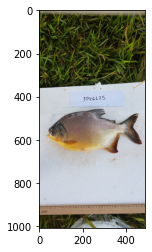

In [ ]:
import io
import requests
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F
from io import BytesIO
from PIL import Image, ExifTags, ImageFile





# r = requests.get('https://storage.labelbox.com/ckmcqrqarbc4b0772go0ytxbv%2Fbbc080c6-b553-a2bf-a93c-1891d0ec5a73-1046625.jpg?Expires=1646779590485&KeyName=labelbox-assets-key-3&Signature=2RrFjc6Ic6x0AxXe7lX2ukECskE', stream=True)
# image = Image.open(io.BytesIO(r.content))

#Pertubação de pixels
# image = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/peixe1_cnnfilters_rgb2.png').convert("RGB")

#100 peixes
image = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/ckz4dow5r8eay0z9i9oef91zg.png').convert("RGB")

# #para pegar máscaras

preprocessing = transforms.Compose([transforms.ToTensor()])
preproc_img = preprocessing(image)

#original
transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=0., std=1.)
])

imagem = transform(image)

plt.imshow(image)
imagem.size()

In [ ]:
normalized_inp = preproc_img.unsqueeze(0).to('cpu')

normalized_inp.requires_grad = True

#original
# out = fcn(normalized_inp)['out']
out = model(normalized_inp)


print(out[0]['masks'][0].shape)

mascara2 = out[0]['masks'][0].detach().cpu().squeeze().numpy()

torch.Size([1, 1008, 490])


In [ ]:
model.children()

<generator object Module.children at 0x7f5d2cecdf20>

In [ ]:
# we will save the conv layer weights in this list
model_weights =[]
#we will save the 49 conv layers in this list
conv_layers = []
# get all the model children as list

#original
# model_children = list(model.children())

#Colocado pela Ju
model_children = list(model.backbone)

#counter to keep count of the conv layers
counter = 0
#append all the conv layers and their respective wights to the list
for i in range(len(model_children)):
    if type(model_children[i]) == nn.Conv2d:
        counter+=1
        model_weights.append(model_children[i].weight)
        conv_layers.append(model_children[i])
    elif type(model_children[i]) == nn.Sequential:
        for j in range(len(model_children[i])):
            for child in model_children[i][j].children():
                if type(child) == nn.Conv2d:
                    counter+=1
                    model_weights.append(child.weight)
                    conv_layers.append(child)
print(f"Total convolution layers: {counter}")
print(conv_layers)

Total convolution layers: 17
[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False), Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False), Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False), Conv2d(256

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

#original

# imagem = imagem.unsqueeze(0)
# imagem = imagem.to(device)

imagem.shape

torch.Size([3, 1008, 490])

In [ ]:
outputs = []
names = []
for layer in conv_layers[0:]:
    imagem = layer(imagem)
    outputs.append(imagem)
    names.append(str(layer))
print(len(outputs))
#print feature_maps
for feature_map in outputs:
    print(feature_map.shape)

17
torch.Size([64, 504, 245])
torch.Size([64, 504, 245])
torch.Size([64, 504, 245])
torch.Size([64, 504, 245])
torch.Size([64, 504, 245])
torch.Size([128, 252, 123])
torch.Size([128, 252, 123])
torch.Size([128, 252, 123])
torch.Size([128, 252, 123])
torch.Size([256, 126, 62])
torch.Size([256, 126, 62])
torch.Size([256, 126, 62])
torch.Size([256, 126, 62])
torch.Size([512, 63, 31])
torch.Size([512, 63, 31])
torch.Size([512, 63, 31])
torch.Size([512, 63, 31])


In [ ]:
processed = []
for feature_map in outputs:
    feature_map = feature_map.squeeze(0)
    gray_scale = torch.sum(feature_map,0)
    gray_scale = gray_scale / feature_map.shape[0]
    processed.append(gray_scale.data.cpu().numpy())
for fm in processed:
    print(fm.shape)

(504, 245)
(504, 245)
(504, 245)
(504, 245)
(504, 245)
(252, 123)
(252, 123)
(252, 123)
(252, 123)
(126, 62)
(126, 62)
(126, 62)
(126, 62)
(63, 31)
(63, 31)
(63, 31)
(63, 31)


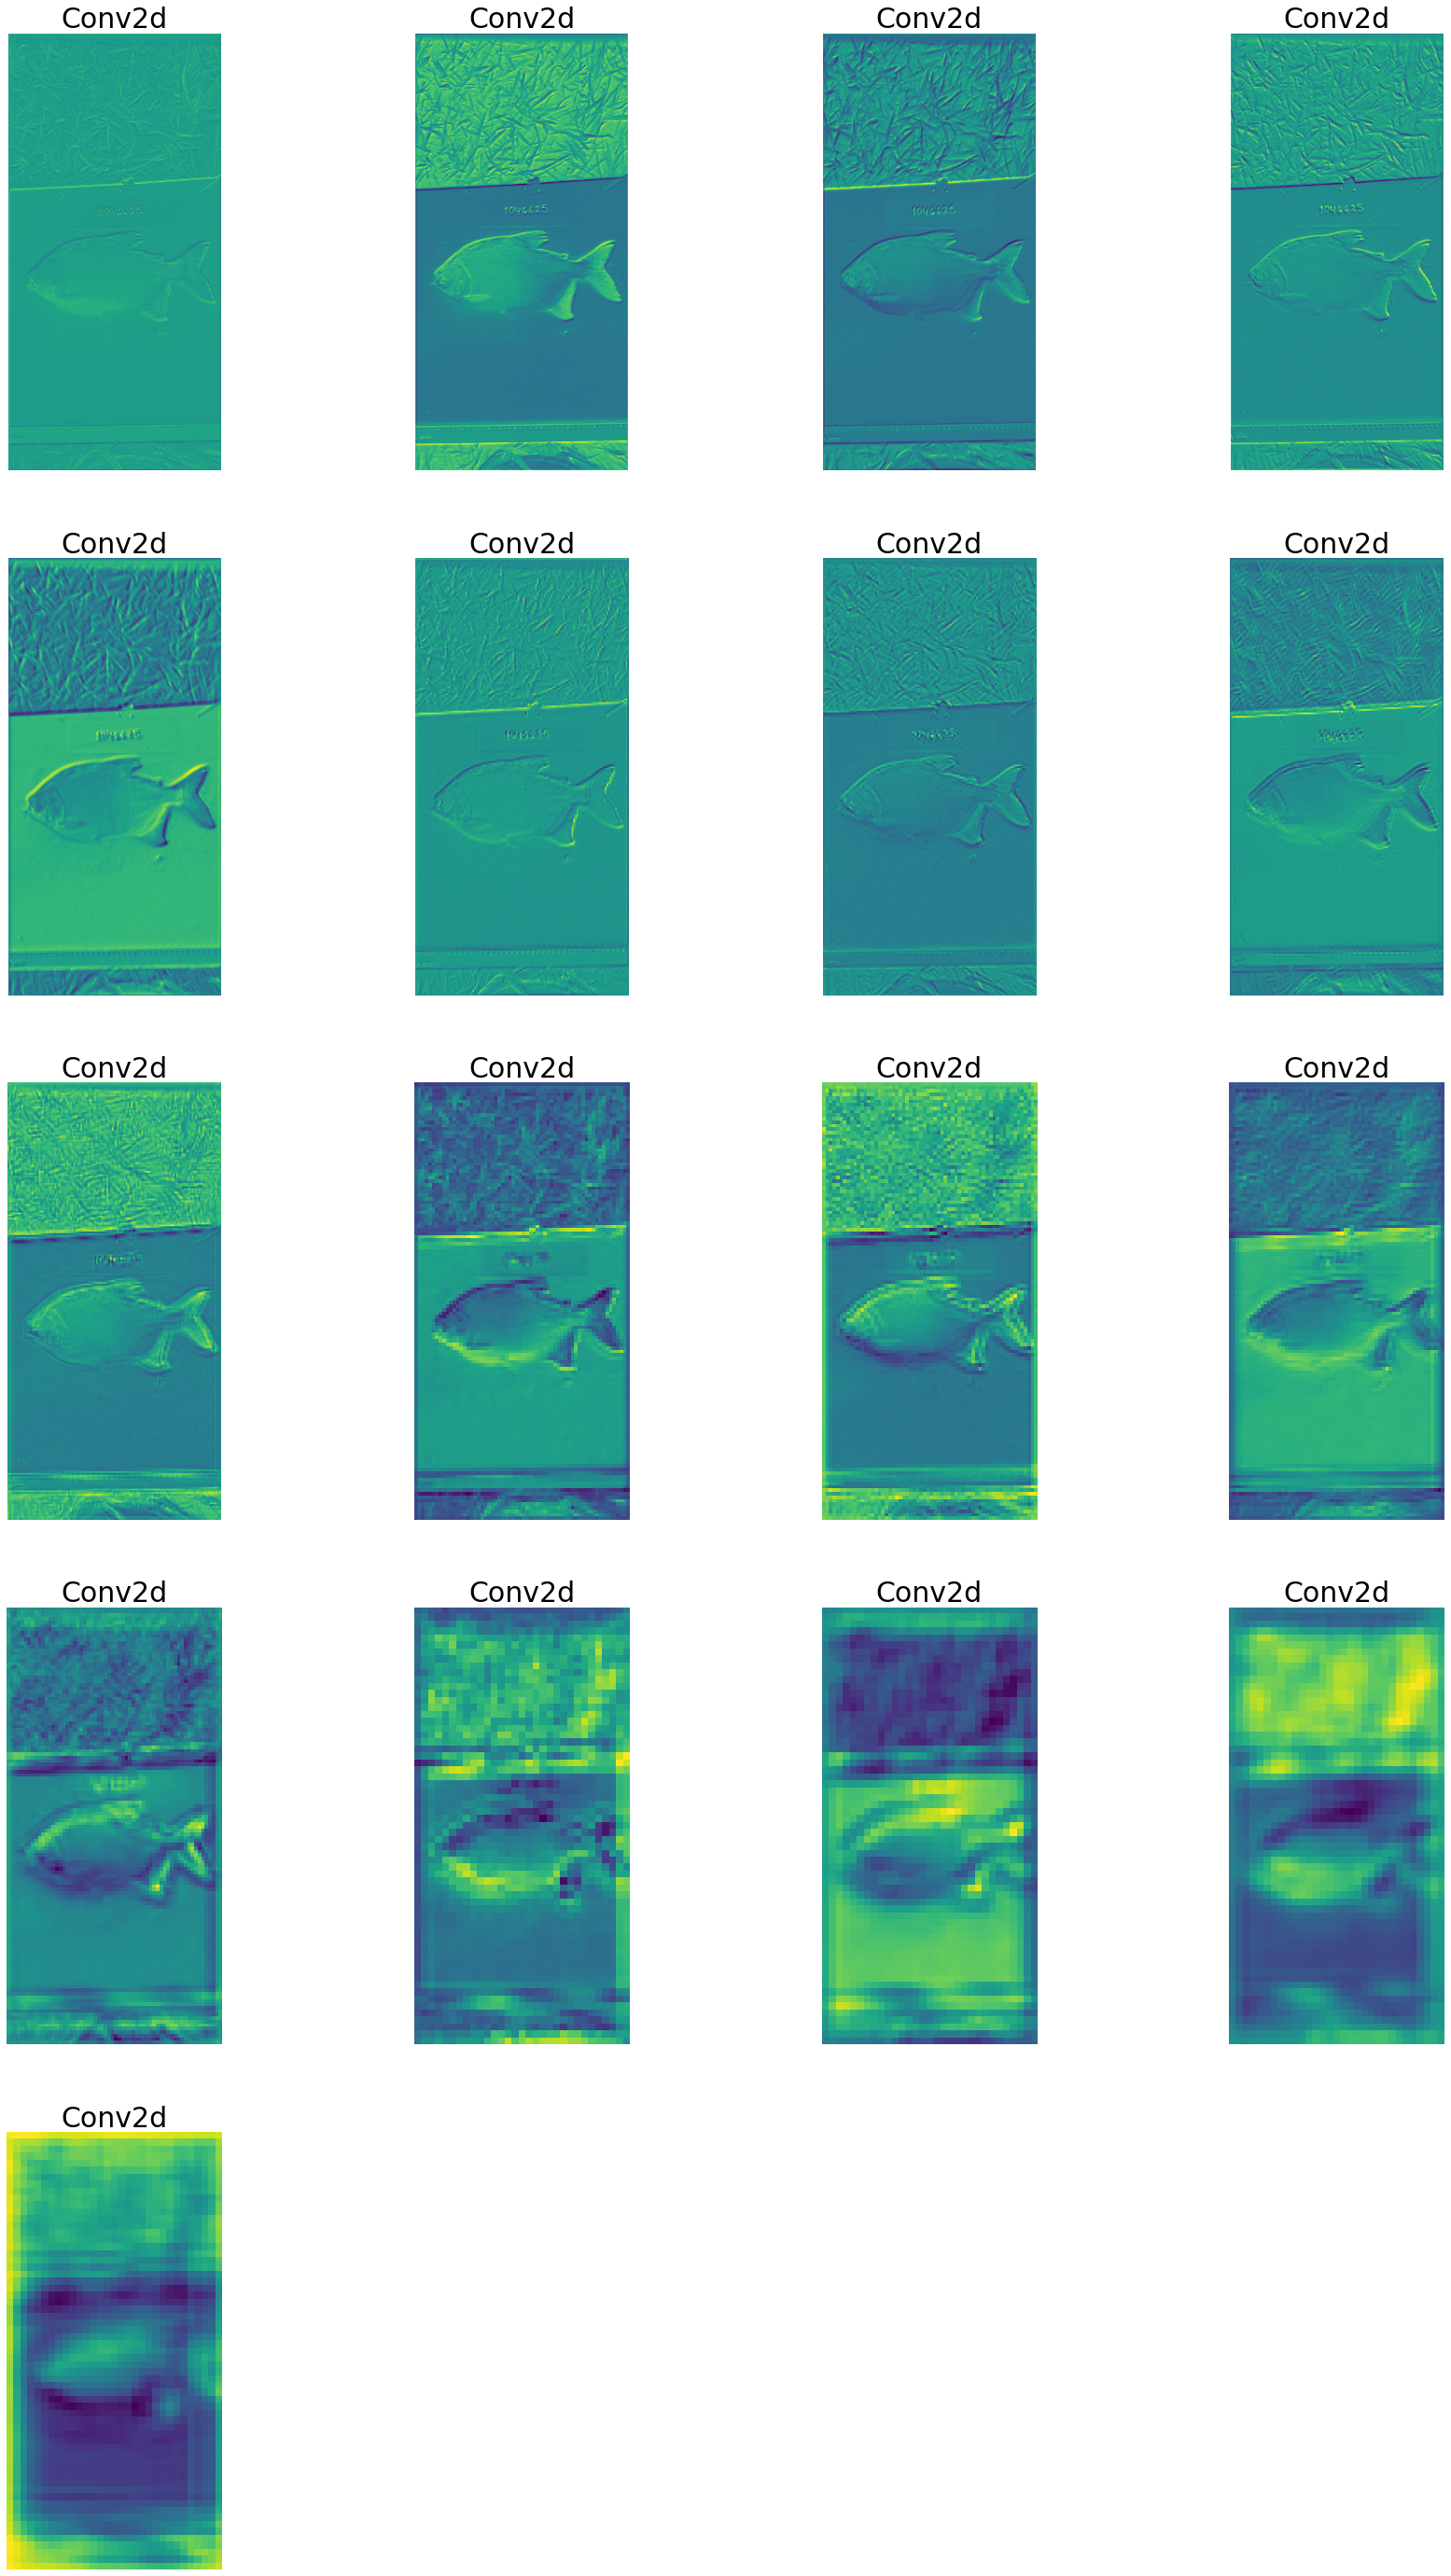

In [ ]:
fig = plt.figure(figsize=(30, 50))
for i in range(len(processed)):
    a = fig.add_subplot(5, 4, i+1)
    imgplot = plt.imshow(processed[i])
    a.axis("off")
    a.set_title(names[i].split('(')[0], fontsize=30)
plt.savefig(str('feature_maps.jpg'), bbox_inches='tight')

In [ ]:
import cv2
result = outputs[0][0]
print(result)

tensor([[-1.4449, -1.8714, -1.9199,  ..., -2.0166, -2.0253, -1.7025],
        [-0.1360, -0.0970, -0.0753,  ..., -0.0865, -0.0603, -0.0659],
        [ 0.0792,  0.0032,  0.1224,  ...,  0.1454,  0.1546,  0.1062],
        ...,
        [ 0.0505,  0.0406,  0.0021,  ...,  0.0639,  0.2044, -0.0188],
        [ 0.0492, -0.0239, -0.0414,  ...,  0.0942, -0.1037,  0.0369],
        [-0.4900, -0.5082, -0.2785,  ..., -0.6391, -0.5457, -0.2726]])


In [ ]:
copia_result = np.zeros((result.shape[0], result.shape[1], 3))


for i in range(len(result)):
 for j in range(len(result[i])):
    if result[i][j]<0:
       copia_result [i][j][0] = 255
       copia_result [i][j][1] = 0
       copia_result [i][j][2] = 0



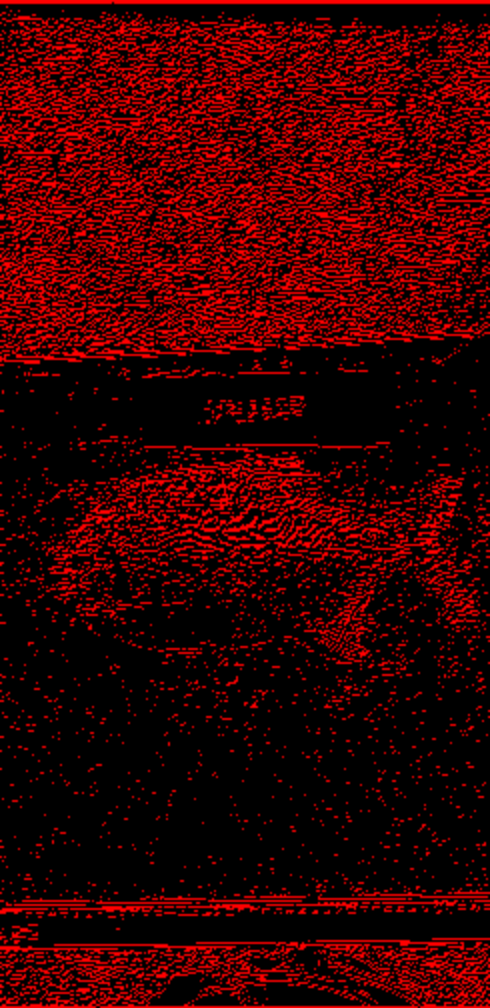

In [ ]:
resultado = cv2.resize(copia_result, (image.size[0], image.size[1]), interpolation = cv2.INTER_LINEAR)

Image.fromarray(np.uint8(resultado))

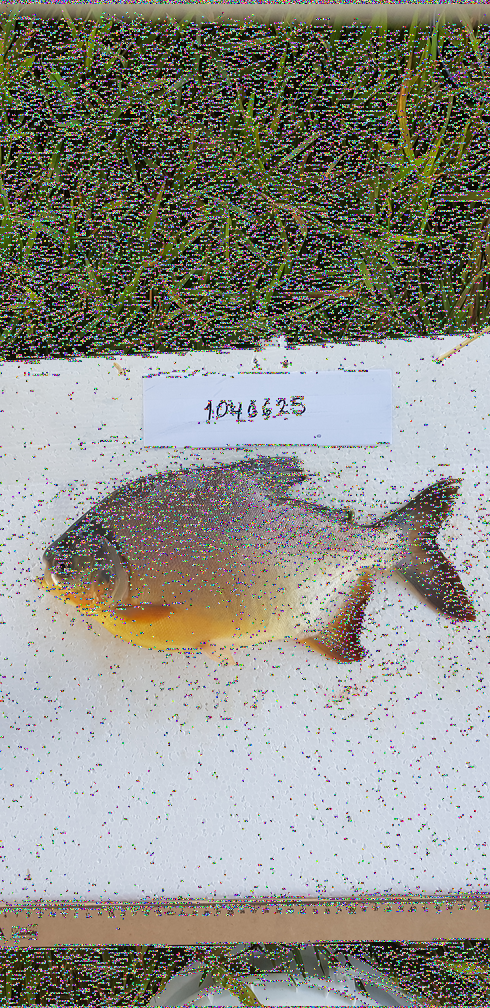

In [ ]:
import random
#Código implementado pela Ju - Pertubação de pixels
# img.show()
copia_img =  np.float32(image.convert("RGB"))

#Matriz zerada da imagem
mask_cam3 = np.zeros((copia_img.shape[0], copia_img.shape[1]))
# result = processed[0]


# #RGB
# for i in range(len(resultado)):
#  for j in range(len(resultado[i])):
#     if resultado[i][j][0]>128:
#        copia_img [i][j][0] = 0
#        copia_img [i][j][1] = 255
#        copia_img [i][j][2] = 0
#        mask_cam3 [i][j] = 1
#       #  print(grayscale_cam[i][j])


#White Noise

# for i in range(len(resultado)):
#   for j in range(len(resultado[i])):
#     if resultado[i][j][0]>128:
#       rdn = random.random()
#       if rdn < 0.5:
#         copia_img [i][j][0] = 0
#         copia_img [i][j][1] = 0
#         copia_img [i][j][2] = 0
#       elif rdn > 0.5:
#         copia_img [i][j][0] = 255
#         copia_img [i][j][1] = 255
#         copia_img [i][j][2] = 255
#       mask_cam3 [i][j] = 1

#Image.fromarray(cam_image)


#Pixels Aleatórios

for i in range(len(resultado)):
  for j in range(len(resultado[i])):
    if resultado[i][j][0]>128:
      copia_img [i][j][0] = random.randint(0, 255)
      copia_img [i][j][1] = random.randint(0, 255)
      copia_img [i][j][2] = random.randint(0, 255)
      mask_cam3 [i][j] = 1


Image.fromarray(np.uint8(copia_img)).save('/content/drive/MyDrive/Colab Notebooks/XAI/peixe1_cnnfilters_rgb2.png')
Image.fromarray(np.uint8(copia_img))

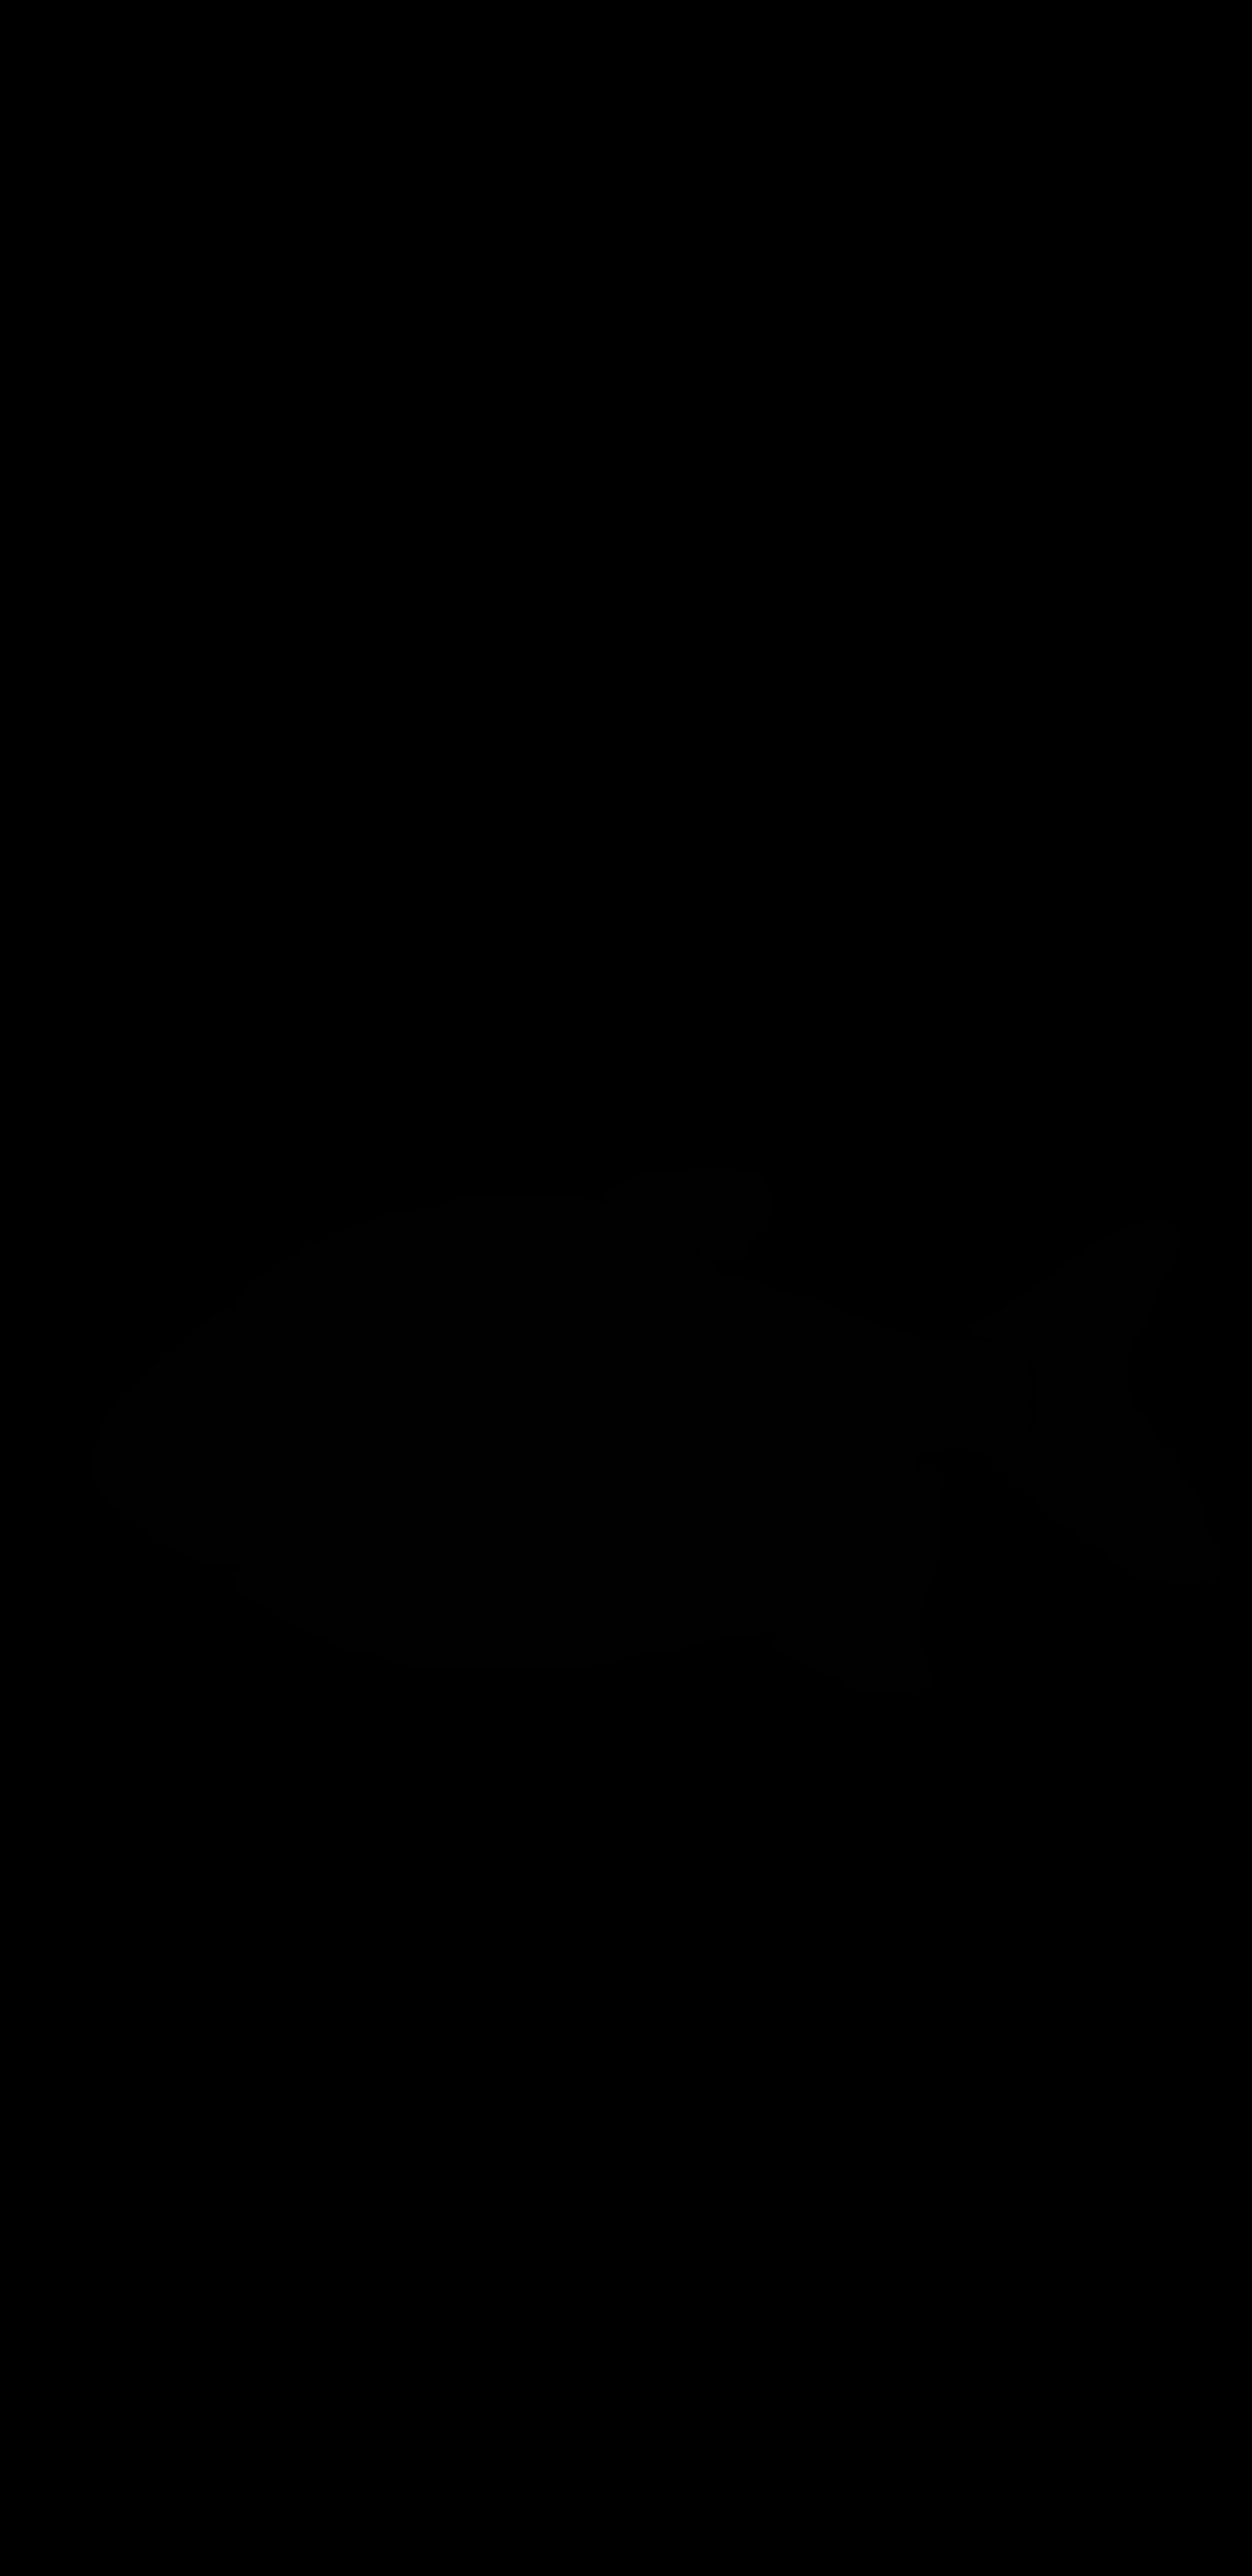

In [ ]:
#Combinação das máscaras
#Imagem ficará preta por conta do valor 1
mascara_merge2 = np.zeros((copia_img.shape[0], copia_img.shape[1]))

for p in out[0]['masks']:
  t = p.squeeze().detach().cpu().numpy()
  for i in range(len(t)):
    for j in range(len(t[i])):
        if t[i][j]>0.5:
          mascara_merge2[i][j] = 1


Image.fromarray(np.uint8(mascara_merge2))

In [ ]:
#intersecção sobre a união
a = np.uint8(mask_cam3)
b = np.uint8(mascara_original)
# b = np.uint8(mascara_merge2)

mask1_area = np.count_nonzero(a == 1)
mask2_area = np.count_nonzero(b == 1)
intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
iou = intersection/(mask1_area+mask2_area-intersection)

print(iou)

0.05880998964207619


In [ ]:
#indice sorensen_dice
dice = np.sum(mask_cam3[mascara_original==1])*2.0 / (np.sum(mask_cam3) + np.sum(mascara_original))
# dice = np.sum(mask_cam3[mascara_merge2==1])*2.0 / (np.sum(mask_cam3) + np.sum(mascara_merge2))
print(dice)

0.06877492698552272


#Layer GradCAM (Segmentation Interpret Captum)

https://captum.ai/tutorials/Segmentation_Interpret



In [ ]:
!pip install captum

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from captum.attr import visualization as viz
from captum.attr import LayerGradCam, FeatureAblation, LayerActivation, LayerAttribution



In [ ]:
from prediction_utils import URLDataset, get_maskrcnn_model, get_transform, display_pred, display_black_mask, display_white_mask, get_coloured_mask, check_resolutions
from torchvision.transforms import ToPILImage
from matplotlib import pyplot as plt
from time import time
import numpy as np
import cv2
import torch
from torchvision.models import resnet50
from captum.attr import visualization as viz
from captum.attr import LayerGradCam, FeatureAblation, LayerActivation, LayerAttribution

model = get_maskrcnn_model(num_classes=4, FROZEN_BLOCKS=1)

model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/XAI/resnet18_checkpoint_355.pth', map_location=torch.device("cpu")))

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(device)
model = model.to(device).eval()

cpu


In [ ]:
"""
This wrapper computes the segmentation model output and sums the pixel scores for
all pixels predicted as each class, returning a tensor with a single value for
each class. This makes it easier to attribute with respect to a single output
scalar, as opposed to an individual pixel output attribution.
"""
def agg_segmentation_wrapper(inp):
    model_out = model(inp)[0]
    #print(model_out)
    # Creates binary matrix with 1 for original argmax class for each pixel
    # and 0 otherwise. Note that this may change when the input is ablated
    # so we use the original argmax predicted above, out_max.
    out_max = torch.argmax(model_out["masks"], dim=1, keepdim=True)
    selected_inds = torch.zeros_like(model_out["masks"]).scatter_(1, out_max, 1)
    return (model_out["masks"] * selected_inds).sum(dim=(2,3))

    #Original
    # return (model_out["masks"][0] * selected_inds).sum(dim=(2,3))


# Alternate wrapper, simply summing each output channel
def wrapper(inp):
    return model(inp)[0]['masks'].sum(dim=(2,3))

In [ ]:

def decode_segmap(image, nc=21, threshold=0.5):

    label_colors = np.array([(0, 0, 0),  # 0=background
               # 1=cabeça, 2=nadadeiras, 3=corpo, 4=?
               (128, 0, 0), (0, 128, 0), (128, 128, 0), (128, 128, 0)])


    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)

    for l in range(0, nc):
        idx = image > threshold
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]

    rgb = np.stack([r, g, b], axis=2)
    return rgb

In [ ]:
import csv


def CalcularIndices4(copia_img, mask_cam, nome, cont, i):



      Image.fromarray(np.uint8(copia_img)).save("/content/drive/MyDrive/Colab Notebooks/XAI/LayersGradCam_Aleatorio/peixe"+str(cont)+"_layers_aleatorio"+str(i)+".png")

      # print("peixe"+str(cont)+"_gradcam_preto"+str(i)+".png")

      img_mask = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Máscaras peixes/"+nome+".png")
      mascara_original = np.asarray(img_mask)

      #intersecção sobre a união
      a = np.uint8(mask_cam)
      b = np.uint8(mascara_original)


      mask1_area = np.count_nonzero(a == 1)
      mask2_area = np.count_nonzero(b == 1)
      intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
      iou = intersection/(mask1_area+mask2_area-intersection)

      # print(iou)


      #sorense dice
      dice = np.sum(mask_cam[mascara_original==1])*2.0 / (np.sum(mask_cam) + np.sum(mascara_original))

      # print(dice)


      with open("/content/drive/MyDrive/Colab Notebooks/XAI/LayersGradCam_Aleatorio/indices_layersgradcam_aleatorio.csv", "a", newline="") as csvfile:
        spamwriter = csv.writer(csvfile, delimiter=";", quotechar="|", quoting=csv.QUOTE_MINIMAL, lineterminator='\n')
        spamwriter.writerow([cont, nome, str(iou), str(dice), i])






In [ ]:
import random
import cv2
import torchvision
from torchvision import models, transforms, utils

contador = 0

for imagens in linhas:
  contador += 1
  nome = imagens[0:25]
  print(nome)
  img = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/"+nome+".png").convert("RGB")
  for c in [1,2,3,4,5]:
    try:
      print(c)
      if c>1:
        num2 = c-1
        img = Image.open("/content/drive/MyDrive/Colab Notebooks/XAI/LayersGradCam_Aleatorio/peixe"+str(contador)+"_layers_aleatorio"+str(num2)+".png").convert("RGB")

      preprocessing = transforms.Compose([transforms.ToTensor()])
      preproc_img = preprocessing(img)

      normalized_inp = preproc_img.unsqueeze(0).to(device)
      normalized_inp.requires_grad = True

      out = model(normalized_inp)

      #Feito pela Ju - tensor estava voltando zerado
      out_mask = out[0]['masks']
      out_labels = out[0]['labels']


      out_max = torch.argmax(out_mask, dim=1, keepdim=True)

      for mask in out_mask:
        rgb = decode_segmap(mask.detach().cpu().squeeze().numpy(), 3, 0.90)


      lgc = LayerGradCam(agg_segmentation_wrapper, model.backbone[7])
      gc_attr = lgc.attribute(normalized_inp, target=0)

      # la = LayerActivation(wrapper,  model.backbone[7])
      # activation = la.attribute(normalized_inp)
      result = gc_attr[0].cpu().permute(1,2,0).detach().numpy()
      result2 = gc_attr[0].cpu().permute(1,2,0).detach().numpy()
      copia_result2 = np.zeros((result2.shape[0], result2.shape[1], 3))

      for k in range(len(result2)):
        for l in range(len(result2[k])):
          if result2[k][l]>-0.5:
            copia_result2 [k][l][0] = 255
            copia_result2 [k][l][1] = 0
            copia_result2 [k][l][2] = 0

      resultado2 = cv2.resize(copia_result2, (img.size[0],img.size[1]), interpolation = cv2.INTER_LINEAR)


      #Perturbação de pixels
      copia_img2 =  np.float32(img.convert("RGB"))

      #Matriz zerada da imagem
      mask_cam2 = np.zeros((copia_img2.shape[0], copia_img2.shape[1]))

      # #RGB - Preto
      # for i in range(len(resultado2)):
      #  for j in range(len(resultado2[i])):
      #     if resultado2[i][j][0]>128:
      #        copia_img2 [i][j][0] = 0
      #        copia_img2 [i][j][1] = 0
      #        copia_img2 [i][j][2] = 0
      #        mask_cam2 [i][j] = 1
      #        # print(grayscale_cam[i][j])

      #White noise
      # for i in range(len(resultado2)):
      #   for j in range(len(resultado2[i])):
      #     if resultado2[i][j][0]>128:
      #       rdn = random.random()
      #       if rdn < 0.5:
      #         copia_img2 [i][j][0] = 0
      #         copia_img2 [i][j][1] = 0
      #         copia_img2 [i][j][2] = 0
      #       elif rdn > 0.5:
      #         copia_img2 [i][j][0] = 255
      #         copia_img2 [i][j][1] = 255
      #         copia_img2 [i][j][2] = 255
      #       mask_cam2 [i][j] = 1

      #Pixels Aleatórios

      for i in range(len(resultado2)):
        for j in range(len(resultado2[i])):
          if resultado2[i][j][0]>128:
            copia_img2 [i][j][0] = random.randint(0, 255)
            copia_img2 [i][j][1] = random.randint(0, 255)
            copia_img2 [i][j][2] = random.randint(0, 255)
            mask_cam2 [i][j] = 1



      CalcularIndices4(copia_img2, mask_cam2, nome, contador, c)

    except:
        break



ckz4dow5r8eay0z9i9oef91zg
1
2
3
4
5
ckz4e0jvq8h73109bbpqs0fps
1
2
3
4
5
ckz4e2n4q8f530z8n9s3ubp7y
1
2
3
4
5
ckz4e3onq8gmi0z9i5c70ay45
1
2
3
4
5
ckz4e4vvo8i6i109bgzla6hms
1
2
3
4
5
ckz4e8ge48hhl0z9ifd9773xk
1
2
3
4
5
ckz4e9ebq8gg20z8ngztba1ez
1
2
3
4
5
ckz4e650k8ig1109b97k528nn
1
2
3
4
5
ckz4e72918ion109b5wbr5raw
1
2
3
4
5
ckz4ea3cz8jbf109bhn9y68q1
1
2
3
4
5
ckz4ebk6g8i8u0z9i60n60f6l
1
2
3
4
5
ckz4edumg8ing0z9ifni9g5t8
1
2
3
4
5
ckz4efrf38kem109b2057fb9a
1
2
3
4
5
ckz4egfr48kh7109bah7xf5az
1
2
3
4
5
ckz4fduq78ntw0z8n630rag87
1
2
3
4
5
ckz4ff6t28o3e0z8neshr668d
1
2
3
4
5
ckz4ffyse8o9s0z8n3zgmd73e
1
2
3
4
5
ckz4fhxu88ool0z8n6rwr1cpm
1
2
3
4
5
ckz4fiupe8rhx109bh3peeyhc
1
2
3
4
5
ckz4fzcn28sui0z8nakiacny4
1
2
ckz4g2msm8tqx0z8n6d9pb3iv
1
2
3
4
5
ckz4g4h098uag0z8nht9q26i8
1
2
3
4
5
ckz4g5tsc8um20z8n9i7a5xw6
1
2
3
4
5
ckz4g6h9v8x8e109b16pefhfo
1
2
3
4
5
ckz4g7nl08v2x0z8nbuek2vjk
1
2
3
4
5
ckz4g09s18vbm109bhm9pcd53
1
2
3
4
5
ckz4g9uib8x7y0z9i2x6dgzf8
1
2
3
4
5
ckz4g17ra8upt0z9ibj0bbdno
1
2
3
4


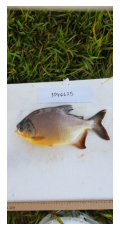

In [ ]:
import torch
import torch.nn as nn
import torchvision

from torchvision import models, transforms, utils
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import scipy.misc
from PIL import Image
import json
%matplotlib inline
import io
import requests


# r = requests.get('https://storage.labelbox.com/ckmcqrqarbc4b0772go0ytxbv%2Fbbc080c6-b553-a2bf-a93c-1891d0ec5a73-1046625.jpg?Expires=1646779590485&KeyName=labelbox-assets-key-3&Signature=2RrFjc6Ic6x0AxXe7lX2ukECskE', stream=True)
# img = Image.open(io.BytesIO(r.content))

#Pertubação de pixels
# img = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/peixe1_layersgradcam_rgb1.png').convert("RGB")

#100 peixes
img = Image.open('/content/drive/MyDrive/Colab Notebooks/XAI/Imagens peixes/ckz4dow5r8eay0z9i9oef91zg.png').convert("RGB")

# Input preprocessing transformation
preprocessing = transforms.Compose([transforms.ToTensor()])
# normalize = transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])

preproc_img = preprocessing(img)
plt.imshow(preproc_img.permute(1,2,0)); plt.axis('off'); plt.show()

tensor([3, 1, 2])


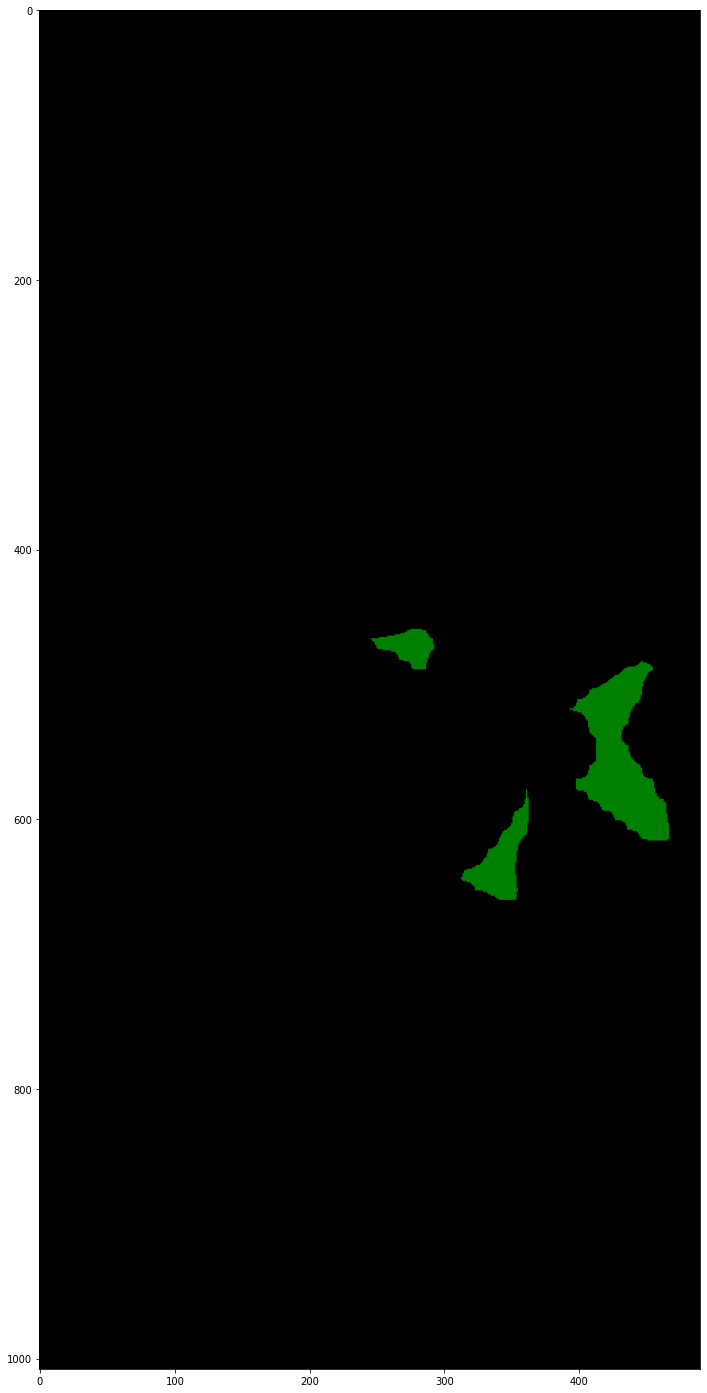

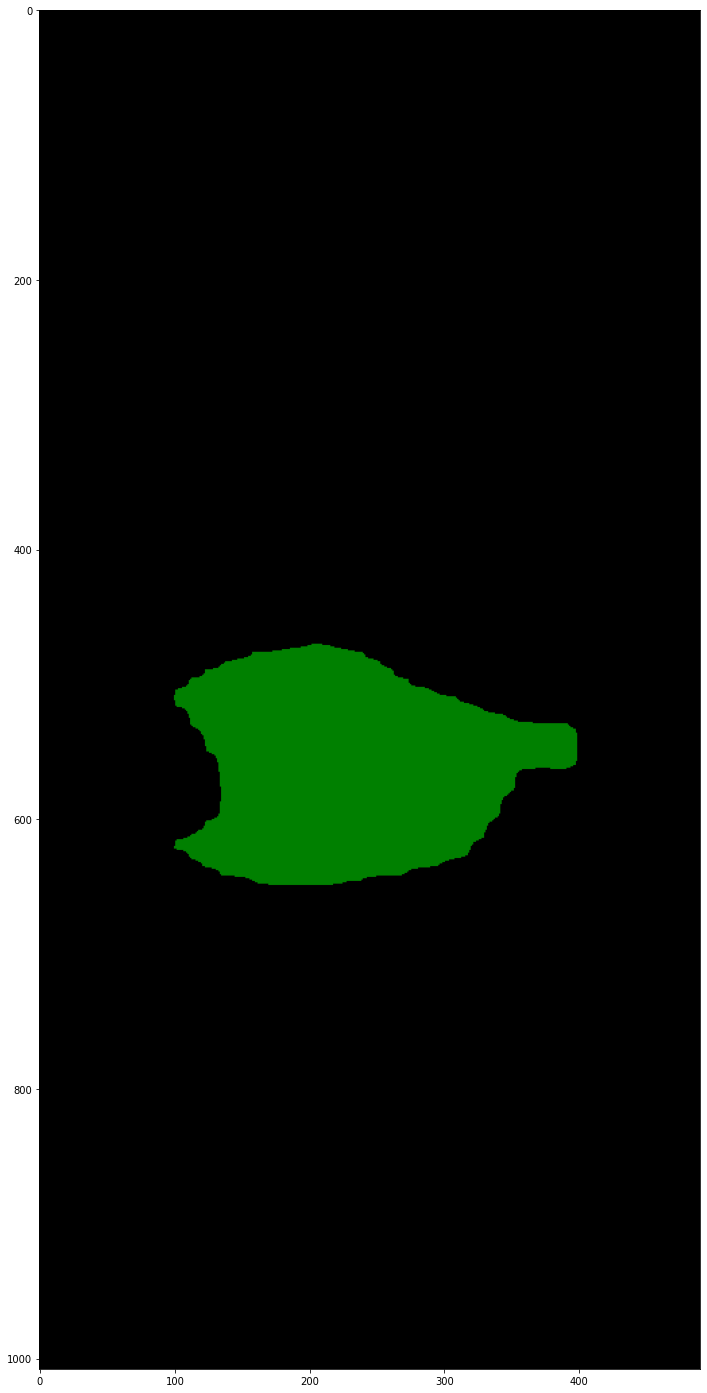

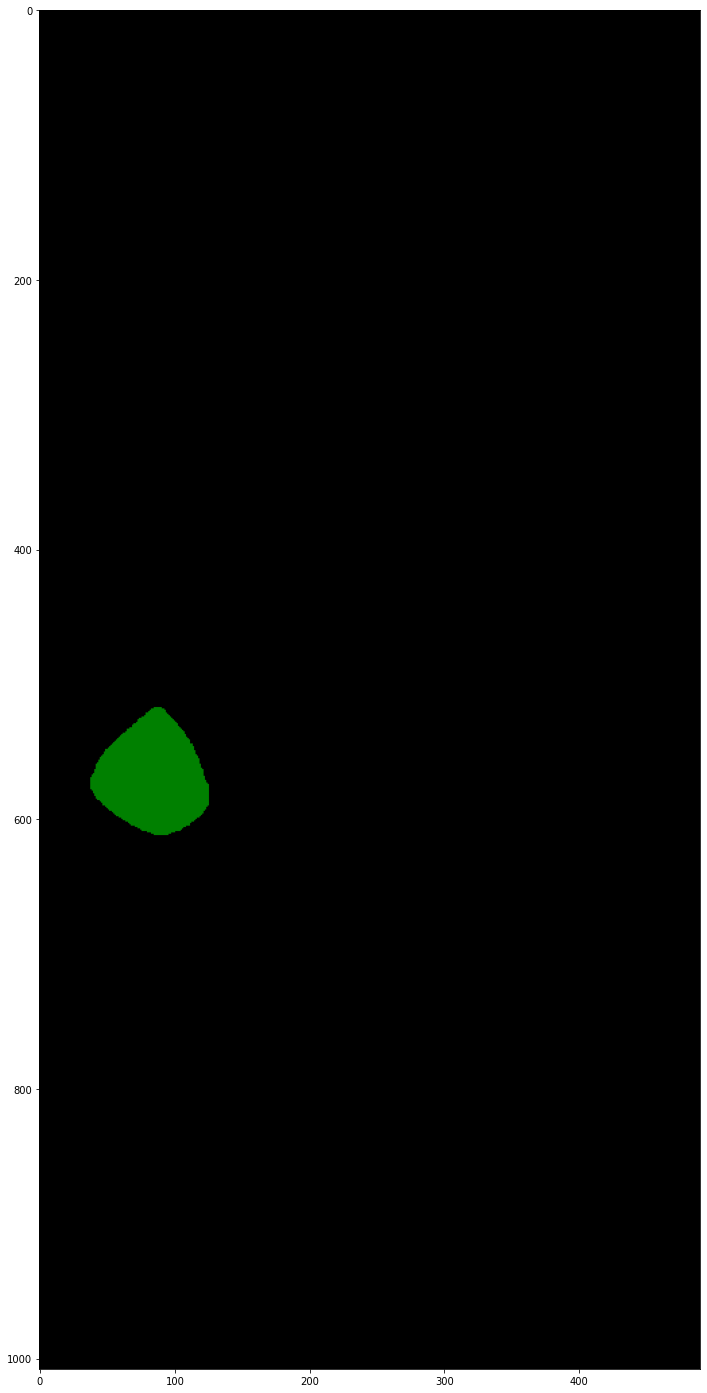

In [ ]:
# Normalize image and compute segmentation output
#original
# normalized_inp = normalize(preproc_img).unsqueeze(0).to(device)

#Feito pela Ju
normalized_inp = preproc_img.unsqueeze(0).to(device)

normalized_inp.requires_grad = True

#original
# out = fcn(normalized_inp)['out']
out = model(normalized_inp)

#Feito pela Ju - tensor estava voltando zerado
out_mask = out[0]['masks']
out_labels = out[0]['labels']

print(out_labels)

# Find most likely segmentation class for each pixel.
#original
out_max = torch.argmax(out_mask, dim=1, keepdim=True)

#Feito pela Ju
# out_max = torch.argmax(normalized_inp, dim=1, keepdim=True)

# Visualize segmentation output using utility method.
for mask in out_mask:
    rgb = decode_segmap(mask.detach().cpu().squeeze().numpy(), 3, 0.90)
    #print(rgb)
    plt.figure(figsize=(25,25))
    plt.imshow(rgb);
    plt.show()


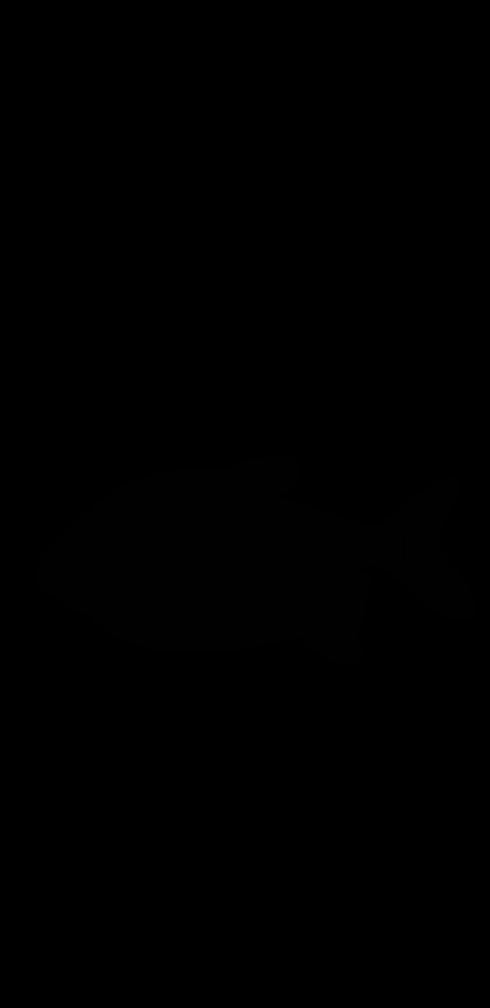

In [ ]:
copia_img =  np.float32(img.convert("RGB"))

mascaras_todas2= np.zeros((copia_img.shape[0], copia_img.shape[1]))

for p in out_mask:
  t = p.squeeze().detach().cpu().numpy()
  for i in range(len(t)):
    for j in range(len(t[i])):
        if t[i][j]>0.5:
          mascaras_todas2[i][j] = 1



Image.fromarray(np.uint8(mascaras_todas2))

In [ ]:
#original
# lgc = LayerGradCam(agg_segmentation_wrapper, fcn.backbone.layer4[2].conv3)

#Feito pela Ju
lgc = LayerGradCam(agg_segmentation_wrapper, model.backbone[7])


In [ ]:
#original
# gc_attr = lgc.attribute(normalized_inp, target=6)

#Feito pela Ju
gc_attr = lgc.attribute(normalized_inp, target=0)

torch.Size([3, 1, 1008, 490])


In [ ]:
#original
# la = LayerActivation(agg_segmentation_wrapper, fcn.backbone.layer4[2].conv3)
# activation = la.attribute(normalized_inp)
# print("Input Shape:", normalized_inp.shape)
# print("Layer Activation Shape:", activation.shape)
# print("Layer GradCAM Shape:", gc_attr.shape)

#Feito pela Ju
la = LayerActivation(wrapper,  model.backbone[7])
activation = la.attribute(normalized_inp)
print("Input Shape:", normalized_inp.shape)
print("Layer Activation Shape:", activation.shape)
print("Layer GradCAM Shape:", gc_attr.shape)

Input Shape: torch.Size([1, 3, 1008, 490])
Layer Activation Shape: torch.Size([1, 512, 42, 21])
Layer GradCAM Shape: torch.Size([1, 1, 42, 21])


In [ ]:
from matplotlib.pyplot import grid
from captum.attr import visualization as viz


# Está dando erro por enquanto - parece ser alguma atualização

# viz.visualize_image_attr(gc_attr[0].cpu().permute(1,2,0).detach().numpy(),sign="all")



In [ ]:
print(gc_attr[gc_attr[:,:] > -0.5])
print(gc_attr.shape)
result = gc_attr[0].cpu().permute(1,2,0).detach().numpy()
print(result.shape)

tensor([-3.9566e-01, -2.6067e-01,  3.7424e-01,  9.0268e-01,  8.1287e-01,
         1.0453e-01,  3.4247e-02,  7.9011e-01,  1.1513e+00,  1.1425e+00,
        -3.3201e-03, -3.3265e-01,  1.8112e-01,  3.3663e-01, -1.5138e-01,
        -5.5467e-02,  3.7049e-01,  1.3115e-01, -5.6442e-02,  1.2819e+00,
         2.3407e+00,  2.6633e+00,  2.5022e+00,  1.7310e+00,  1.8865e+00,
        -3.3141e-01,  1.2666e+00,  4.8213e-01,  4.4561e-01,  4.8508e-01,
         4.9327e-01,  7.6294e-01,  1.2721e+00,  1.0893e+00,  1.2075e+00,
         4.2642e-01,  2.1765e+00,  3.6661e+00,  2.3557e+00,  2.7894e+00,
         3.4015e-02, -4.1102e-01,  3.7590e-01,  8.4157e-01,  1.3255e+00,
         1.2427e+00,  1.6188e+00,  1.6422e+00,  1.1973e+00,  9.8931e-01,
         7.9850e-01,  8.2935e-01,  2.7256e+00,  1.4124e+00,  1.8949e+00,
         4.9415e+00,  4.1621e+00,  7.3043e-01,  3.4697e-01,  9.2774e-01,
         1.4009e+00,  1.4540e+00,  1.3600e+00,  1.3416e+00,  1.2888e+00,
         1.1564e+00,  1.1358e+00,  1.0849e+00,  2.5

In [ ]:
import cv2
result2 = gc_attr[0].cpu().permute(1,2,0).detach().squeeze().numpy()
print(result2.shape)

(42, 21)


In [ ]:
copia_result2 = np.zeros((result2.shape[0], result2.shape[1], 3))

for i in range(len(result2)):
 for j in range(len(result2[i])):
    if result2[i][j]>-0.5:
       copia_result2 [i][j][0] = 255
       copia_result2 [i][j][1] = 0
       copia_result2 [i][j][2] = 0

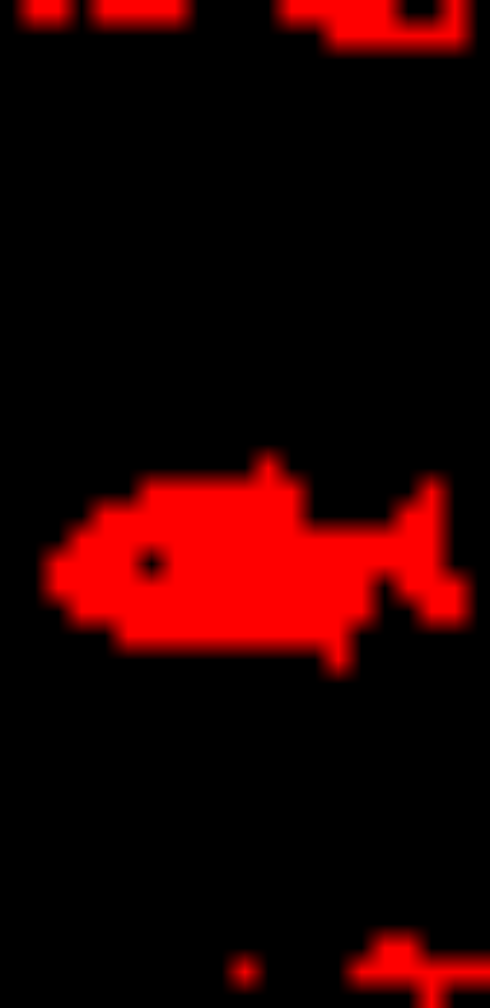

In [ ]:
resultado2 = cv2.resize(copia_result2, (img.size[0],img.size[1]), interpolation = cv2.INTER_LINEAR)
Image.fromarray(np.uint8(resultado2))

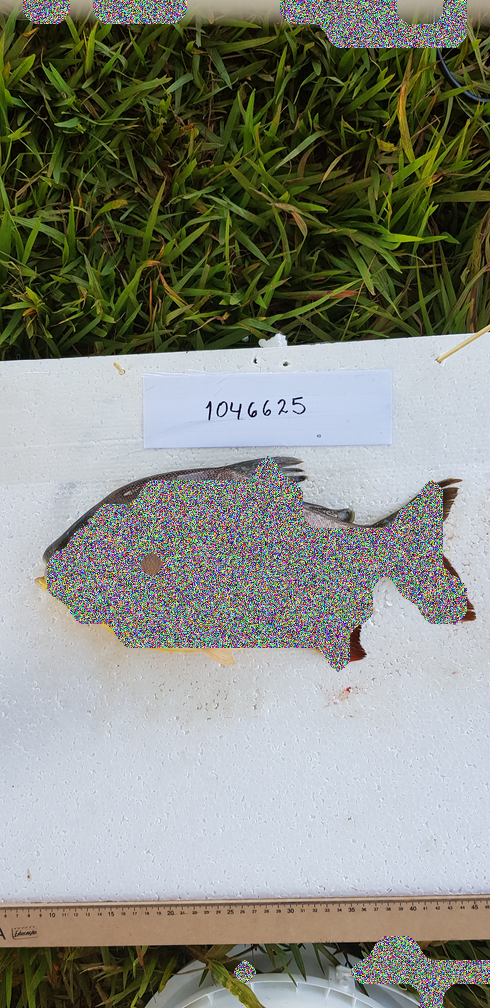

In [ ]:
import random
#Código implementado pela Ju - Pertubação de pixels

copia_img2 =  np.float32(img.convert("RGB"))

#Matriz zerada da imagem
mask_cam2 = np.zeros((copia_img2.shape[0], copia_img2.shape[1]))

# #RGB
# for i in range(len(resultado2)):
#  for j in range(len(resultado2[i])):
#     if resultado2[i][j][0]>128:
#        copia_img2 [i][j][0] = 255
#        copia_img2 [i][j][1] = 0
#        copia_img2 [i][j][2] = 0
#        mask_cam2 [i][j] = 1
#        # print(grayscale_cam[i][j])

#White noise
# for i in range(len(resultado2)):
#   for j in range(len(resultado2[i])):
#     if resultado2[i][j][0]>128:
#       rdn = random.random()
#       if rdn < 0.5:
#         copia_img2 [i][j][0] = 0
#         copia_img2 [i][j][1] = 0
#         copia_img2 [i][j][2] = 0
#       elif rdn > 0.5:
#         copia_img2 [i][j][0] = 255
#         copia_img2 [i][j][1] = 255
#         copia_img2 [i][j][2] = 255
#       mask_cam2 [i][j] = 1



#Pixels Aleatórios

for i in range(len(resultado2)):
  for j in range(len(resultado2[i])):
    if resultado2[i][j][0]>128:
      copia_img2 [i][j][0] = random.randint(0, 255)
      copia_img2 [i][j][1] = random.randint(0, 255)
      copia_img2 [i][j][2] = random.randint(0, 255)
      mask_cam2 [i][j] = 1



Image.fromarray(np.uint8(copia_img2)).save('/content/drive/MyDrive/Colab Notebooks/XAI/peixe1_layersgradcam_rgb1.png')
Image.fromarray(np.uint8(copia_img2))



(1008, 490)


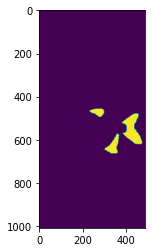

In [ ]:
mascara = out[0]['masks'][0].detach().cpu().squeeze().numpy()
aux_mask_uint8 = 255 * np.uint8(mascara > 0.5)
aux_mask_float = np.float32(mascara > 0.5)
plt.imshow(aux_mask_float);
print(aux_mask_float.shape)


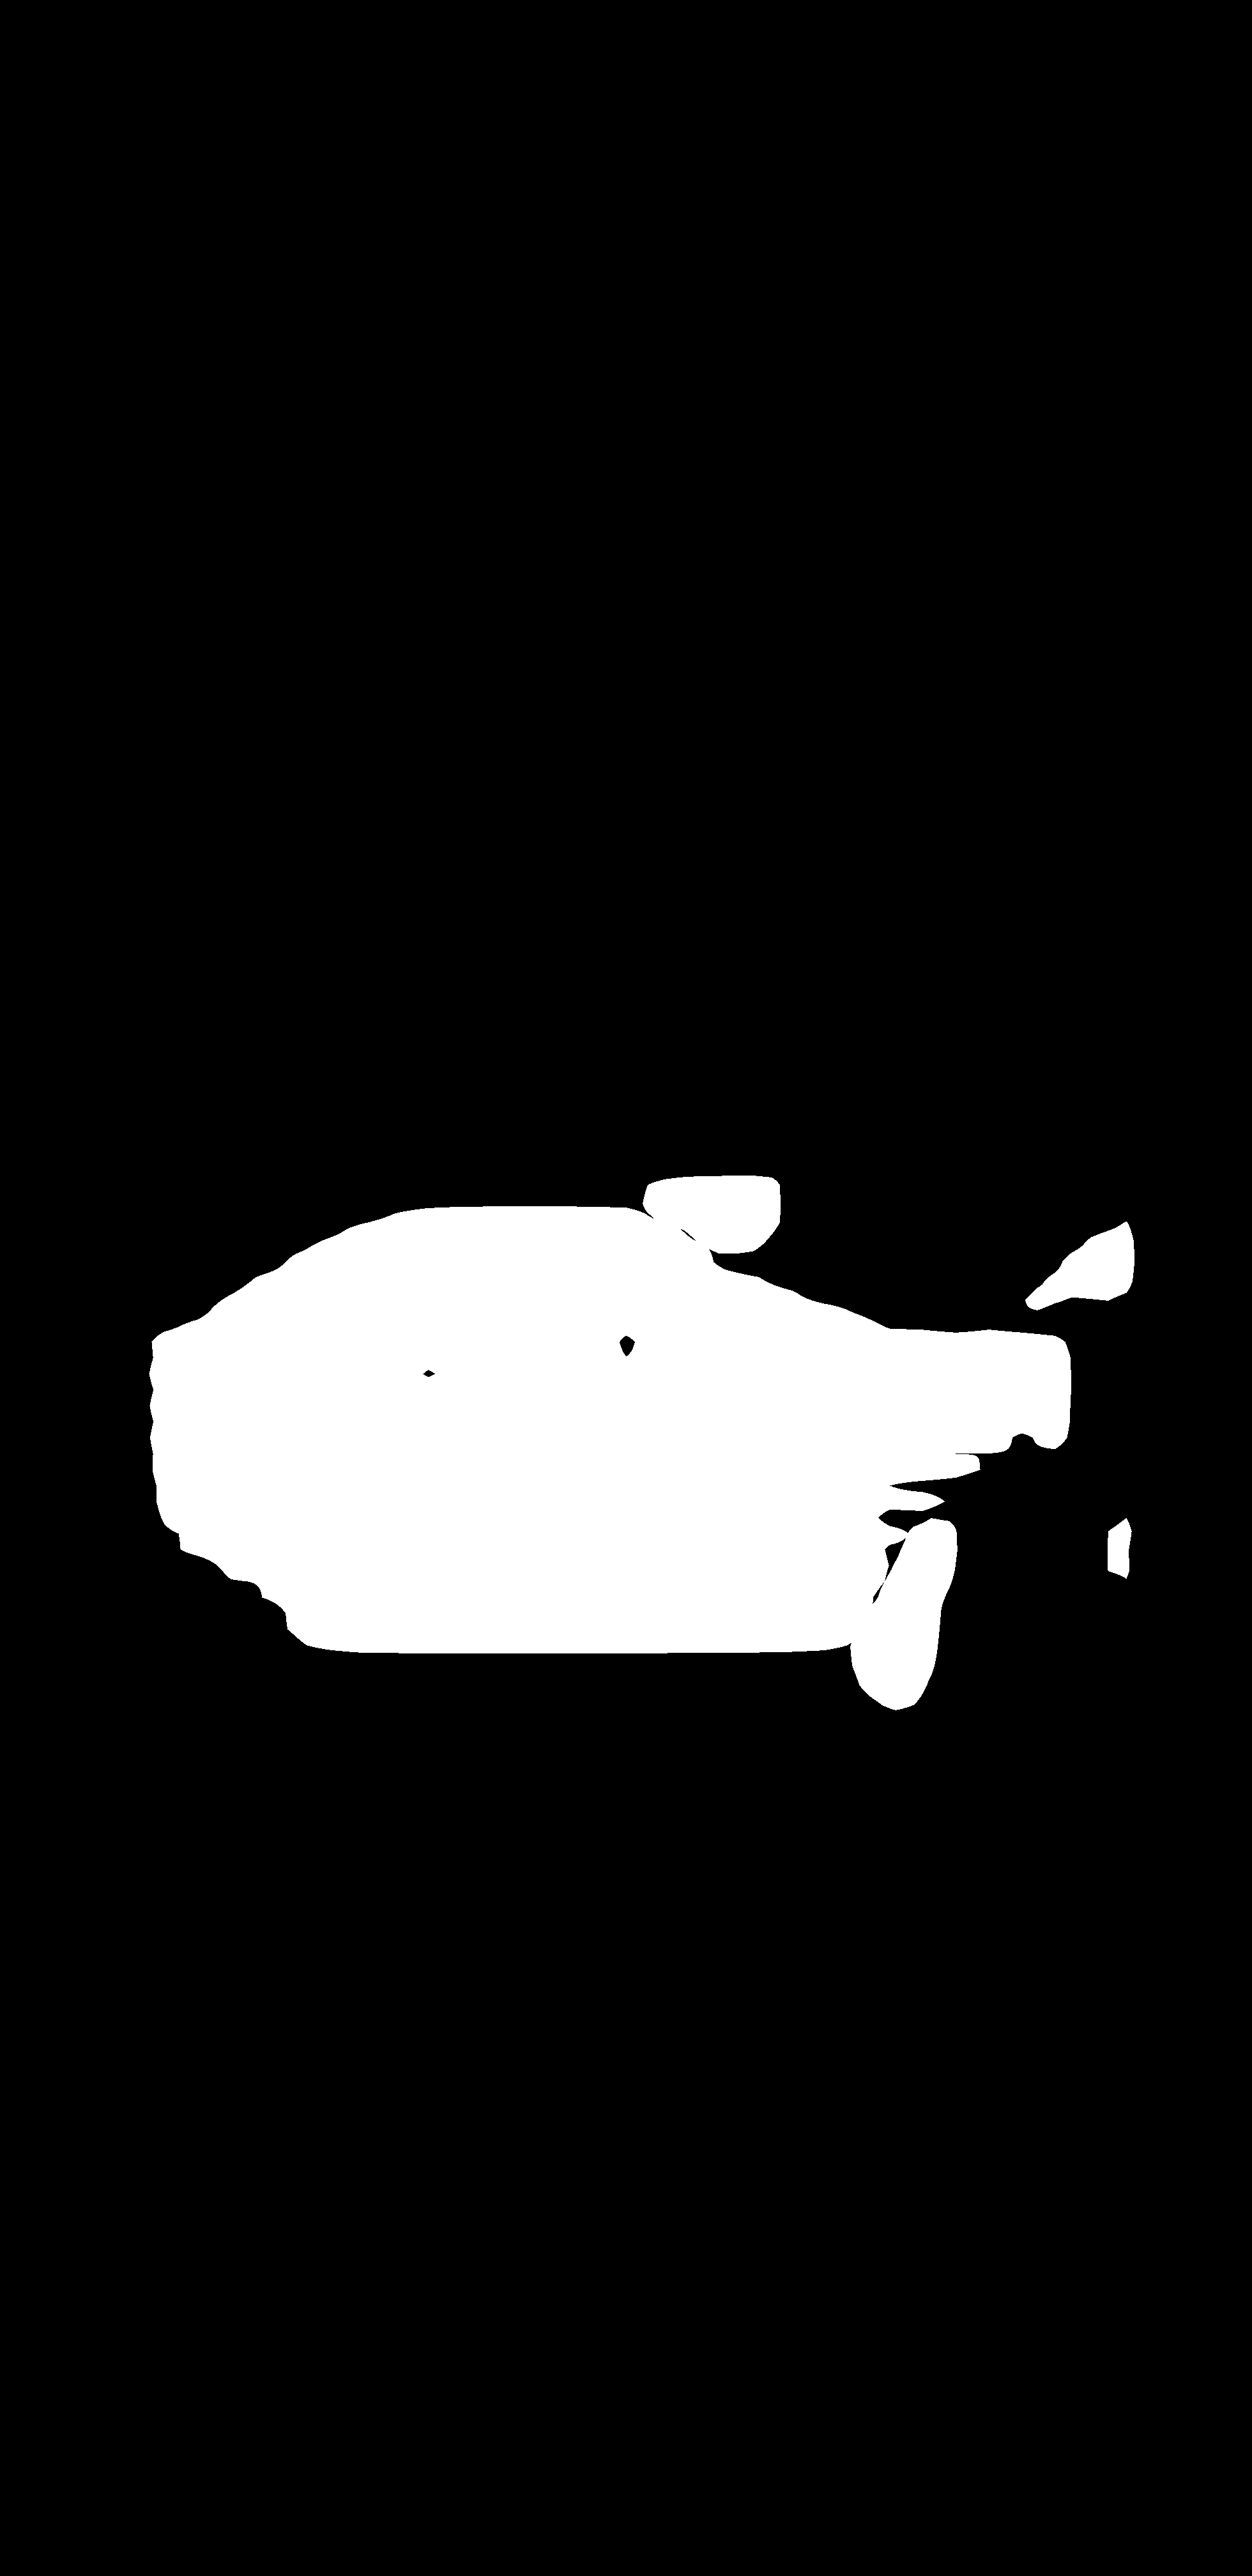

In [ ]:
# Image.fromarray(np.uint8(mask_cam2)*255).convert('RGB')
# Image.fromarray(np.uint8(aux_mask_float*255), "L")
Image.fromarray(np.uint8(mascaras_todas2*255), "L")

In [ ]:
#intersecção sobre a união
a = np.uint8(mask_cam2)
b = np.uint8(mascara_original)
# b = np.uint8(aux_mask_float)
# b = np.uint8(mascaras_todas2)

mask1_area = np.count_nonzero(a == 1)
mask2_area = np.count_nonzero(b == 1)
intersection = np.count_nonzero(np.logical_and(a==1,  b==1))
iou = intersection/(mask1_area+mask2_area-intersection)

print(iou)

0.3792870892051761


In [ ]:
#indice sorensen_dice
dice = np.sum(mask_cam2[mascara_original==1])*2.0 / (np.sum(mask_cam2) + np.sum(mascara_original))
# dice = np.sum(mask_cam2[aux_mask_float==1])*2.0 / (np.sum(mask_cam2) + np.sum(aux_mask_float))
# dice = np.sum(mask_cam2[mascaras_todas2==1])*2.0 / (np.sum(mask_cam2) + np.sum(mascaras_todas2))
print(dice)

0.29491612452135535
